# Importing Libraries & Data

In [137]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [241]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.1 MB/s eta 0:00:00


In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from category_encoders import OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import math
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [139]:
df=pd.read_csv('/content/drive/MyDrive/heart_attack_prediction_indonesia.csv')

#EDA


##Notes:
* there is no duplicates.
* there is no nulls except ``alcohol_consumption``. the percentage of it is: **~60%**
---
####**Numarical Columns:**

* ``cholesterol_level`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* The minimum of ``waist_circumference`` isn't normal (isn't even insight). The Min should be 45. The Max is ok (Look at ***Numbers & Researchs*** Section).
* ``sleep_hours`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* ``blood_pressure_systolic`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* ``blood_pressure_diastolic`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* ``fasting_blood_sugar`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* ``cholesterol_hdl`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* The minimum of ``cholesterol_ldl`` isn't normal (isn't even insight). The Min should be 10. The Max is ok (Look at ***Numbers & Researchs*** Section).
* ``triglycerides`` is in the normal range (Look at ***Numbers & Researchs*** Section).
---
####**Catigorical Columns:**
``hypertension``, ``diabetes``, ``obesity``,``family_history``, ``previous_heart_disease``, ``medication_usage``, ``participated_in_free_screening``, ``heart_attack`` : Aren't Numrical but **Binary** Columns.

In [140]:
df.shape

(158355, 28)

In [141]:
df.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,Male,Rural,Middle,0,1,211,0,83,0,...,62,173,48,121,101,Normal,0,0,0,0
1,53,Female,Urban,Low,0,0,208,0,106,1,...,76,70,58,83,138,Normal,1,0,1,0
2,62,Female,Urban,Low,0,0,231,1,112,1,...,74,118,69,130,171,Abnormal,0,1,0,1
3,73,Male,Urban,Low,1,0,202,0,82,1,...,65,98,52,85,146,Normal,0,1,1,0
4,52,Male,Urban,Middle,1,0,232,0,89,0,...,75,104,59,127,139,Normal,1,0,1,1


In [142]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          # 'Outliars':outliars,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df



In [143]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[54, 56, 55, 52, 53, 57, 58, 51, 50, 59]",66,0,0.000000,0
1,gender,object,"[Male, Female]",2,0,0.000000,0
2,region,object,"[Urban, Rural]",2,0,0.000000,0
3,income_level,object,"[Middle, Low, High]",3,0,0.000000,0
4,hypertension,int64,"[0, 1]",2,0,0.000000,0
5,diabetes,int64,"[0, 1]",2,0,0.000000,0
6,cholesterol_level,int64,"[203, 199, 198, 196, 201, 197, 207, 195, 200, ...",247,0,0.000000,0
7,obesity,int64,"[0, 1]",2,0,0.000000,0
8,waist_circumference,int64,"[91, 93, 94, 96, 95, 92, 98, 89, 90, 97]",136,0,0.000000,0
9,family_history,int64,"[0, 1]",2,0,0.000000,0


In [144]:
df[df['cholesterol_ldl']<0]

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
18255,81,Female,Urban,Low,0,0,247,0,109,0,...,62,97,65,-13,157,Normal,0,1,1,0
21179,49,Male,Urban,Middle,1,0,226,0,85,0,...,87,140,63,-7,143,Normal,0,0,1,0
32874,56,Female,Urban,Low,1,0,240,1,105,0,...,84,101,37,-5,179,Normal,0,1,1,1
44781,70,Male,Rural,Middle,0,0,264,0,110,0,...,92,93,23,-18,150,Normal,0,1,0,0
46253,61,Female,Urban,Low,0,1,132,0,101,0,...,77,120,51,-19,98,Normal,0,0,1,1
59310,59,Female,Urban,Low,0,0,219,0,96,1,...,79,91,44,-4,144,Normal,0,1,0,0
66224,53,Female,Urban,Middle,0,1,209,0,70,0,...,93,131,40,-15,200,Normal,0,1,1,0
69547,62,Female,Urban,Middle,0,0,156,0,104,1,...,78,118,48,-2,246,Normal,0,0,1,0
102573,50,Male,Urban,Low,0,1,158,1,108,0,...,72,70,53,-9,117,Normal,0,0,1,0
111180,65,Male,Urban,Low,0,0,164,0,69,0,...,67,99,60,-7,241,Abnormal,0,0,1,0


In [145]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,158355.0,54.543778,11.910897,25.0,46.000000,55.000000,63.00000,90.0
hypertension,158355.0,0.299069,0.457851,0.0,0.000000,0.000000,1.00000,1.0
diabetes,158355.0,0.199804,0.399854,0.0,0.000000,0.000000,0.00000,1.0
cholesterol_level,158355.0,199.533264,39.737565,100.0,172.000000,199.000000,226.00000,350.0
obesity,158355.0,0.249901,0.432957,0.0,0.000000,0.000000,0.00000,1.0
waist_circumference,158355.0,93.268504,16.382205,20.0,82.000000,93.000000,104.00000,173.0
family_history,158355.0,0.300218,0.458354,0.0,0.000000,0.000000,1.00000,1.0
sleep_hours,158355.0,6.480064,1.425398,3.0,5.492985,6.507461,7.52064,9.0
blood_pressure_systolic,158355.0,129.515772,15.005641,61.0,119.000000,130.000000,140.00000,199.0
blood_pressure_diastolic,158355.0,79.490809,10.002964,37.0,73.000000,80.000000,86.00000,127.0


#Preaprosscing:

##Notes:

###Numbers & Researchs:
---
####-**Numbers**
| Variable | Minimum value (alive patient) | Maximum value (critical but possible alive patient) | Unit | Note |
|---|---:|---:|---|---|
| cholesterol_level (Total Cholesterol) | 80 | 500 | mg/dL | Very low or very high values can occur clinically |
| waist_circumference | 45 | 220 | cm | Very high values represent severe obesity/metabolic risk |
| sleep_hours | 1 | 18 | hours/day | Extreme short or long sleep durations can be recorded |
| blood_pressure_systolic | 60 | 260 | mmHg | Severe hypotension or hypertension may occur in living patients |
| blood_pressure_diastolic | 30 | 160 | mmHg | Extreme values are clinically possible |
| fasting_blood_sugar | 30 | 700 | mg/dL | Severe hyperglycemia has been reported in living patients |
| cholesterol_hdl | 5 | 120 | mg/dL | Extremely low/high HDL values are possible |
| cholesterol_ldl | 10 | 400 | mg/dL | Very high LDL can occur clinically |
| triglycerides | 20 | 2000 | mg/dL | Severe hypertriglyceridemia can occur in living patients |

######-**Note:**
* The clinical interpretation follows Asian-specific metabolic risk thresholds where available.
* Asian populations may develop metabolic complications at lower waist circumference and BMI values compared with Western populations.
* Extreme values represent medically severe but potentially survivable conditions and should not be interpreted as death-related values.
---

#### Researchs (Verified References)

| Variables supported | Reference | Type | Supports | Link |
|---|---|---|---|---|
| Waist circumference, Asian population risk | WHO Expert Consultation. "Appropriate body-mass index for Asian populations and its implications for policy and intervention strategies." The Lancet (2004) | Expert Consultation / Review | Supports Asian-specific obesity and metabolic risk interpretation | https://doi.org/10.1016/S0140-6736(03)15268-3 |
| Waist circumference, glucose, HDL, triglycerides, blood pressure | Alberti KGMM et al. "Harmonizing the Metabolic Syndrome." Circulation (2009) | Scientific Statement | Supports metabolic syndrome components and ethnic waist considerations | https://doi.org/10.1161/CIRCULATIONAHA.109.192644 |
| Blood pressure categories | Indonesian Society of Hypertension (InaSH). "Konsensus Penanganan Hipertensi." (2019) | Clinical Guideline | Supports BP classification used in Indonesian clinical practice | https://inash.or.id |
| Fasting blood glucose classification | American Diabetes Association. Standards of Care in Diabetes | Clinical Guideline | Supports normal glucose, prediabetes, diabetes thresholds | https://diabetesjournals.org/care/issue |
| Total cholesterol, LDL, HDL, triglycerides | National Cholesterol Education Program (NCEP ATP III) | Clinical Guideline | Supports lipid profile categories | https://www.nhlbi.nih.gov/files/docs/guidelines/atp3xsum.pdf |
| Severe triglycerides | Berglund L et al. "Evaluation and Treatment of Hypertriglyceridemia." Circulation (2012) | Scientific Statement | Supports severe and very severe triglyceride categories | https://doi.org/10.1161/CIR.0b013e3182160726 |
| Sleep duration and health risks | Itani O et al. "Short sleep duration and health outcomes: systematic review, meta-analysis, and meta-regression." Sleep Medicine (2017) | Systematic Review + Meta-analysis | Supports sleep duration association with metabolic/health risks | https://doi.org/10.1016/j.sleep.2017.05.015 |
| Indonesian adult health measurements | Indonesia Basic Health Research (Riskesdas) | Population Survey | Supports Indonesian population health data | https://www.badankebijakan.kemkes.go.id |

---


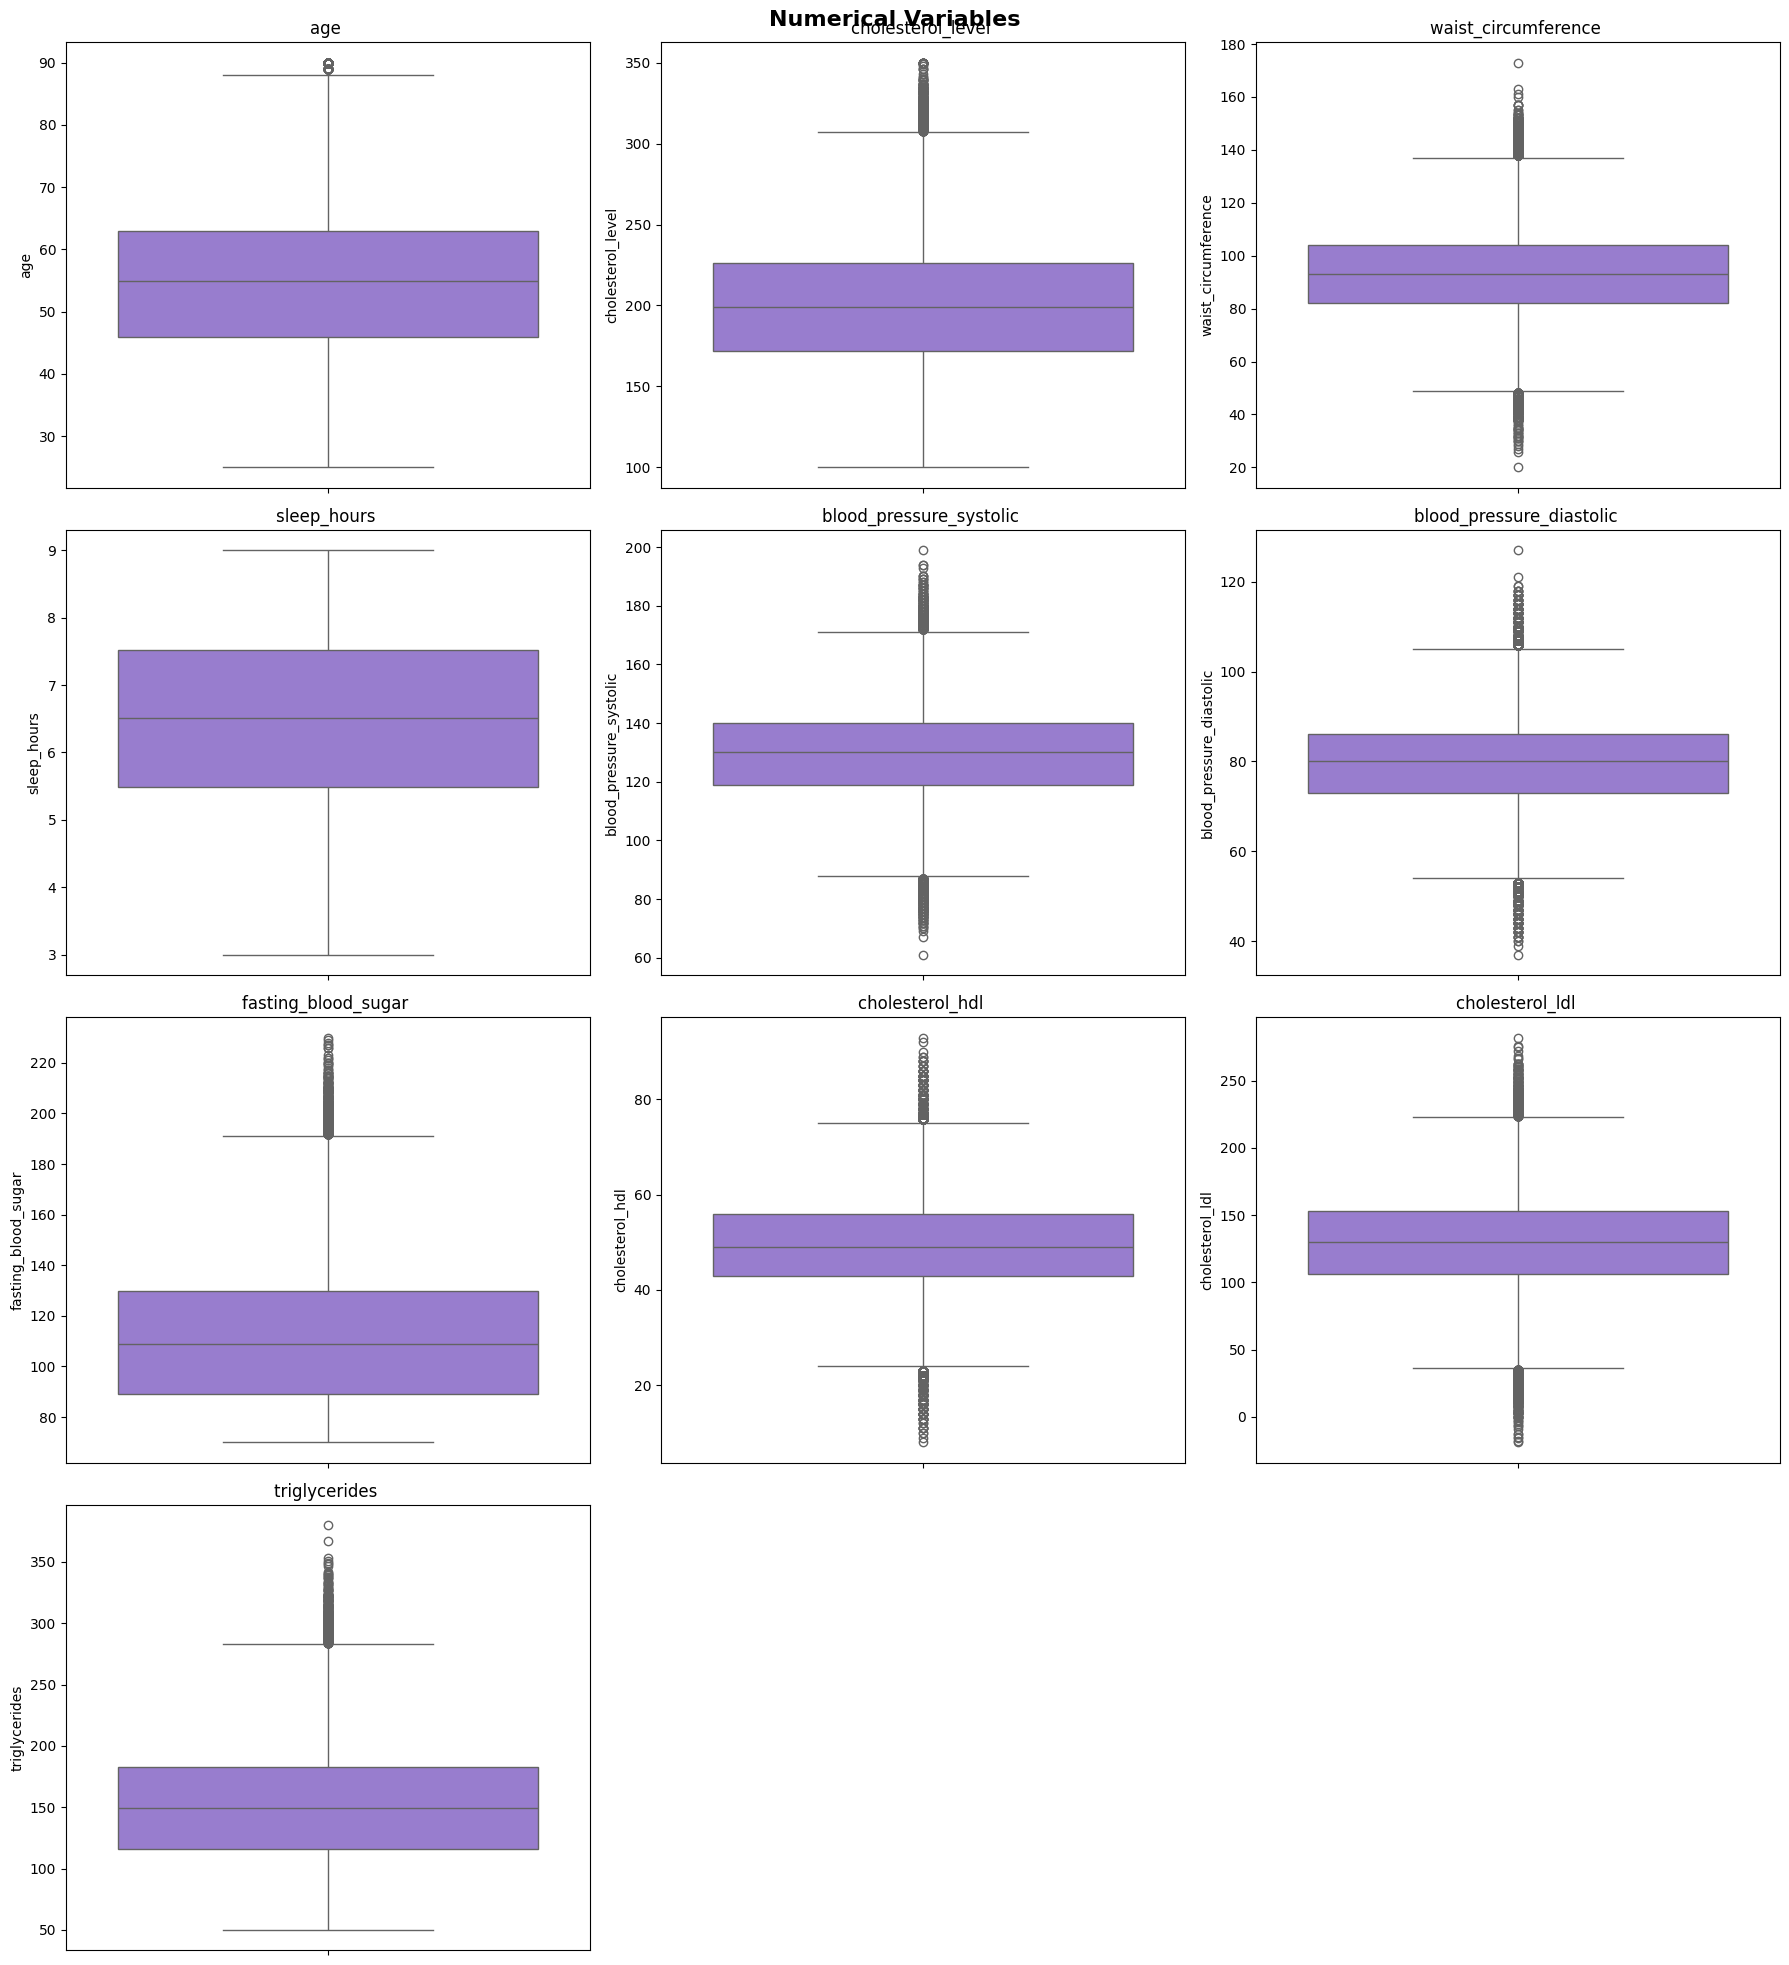

In [146]:
# nums=df.select_dtypes(include=['int64','float64']).columns
nums=['age','cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(nums):
    sns.boxplot(data=df, y=col, ax=axes[i],color='#9370DB')
    fig = px.box(df, x=col, points="all")
    axes[i].set_title(f'{col} ', fontsize=12)
    axes[i].set_ylabel(col)

for j in range(len(nums), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

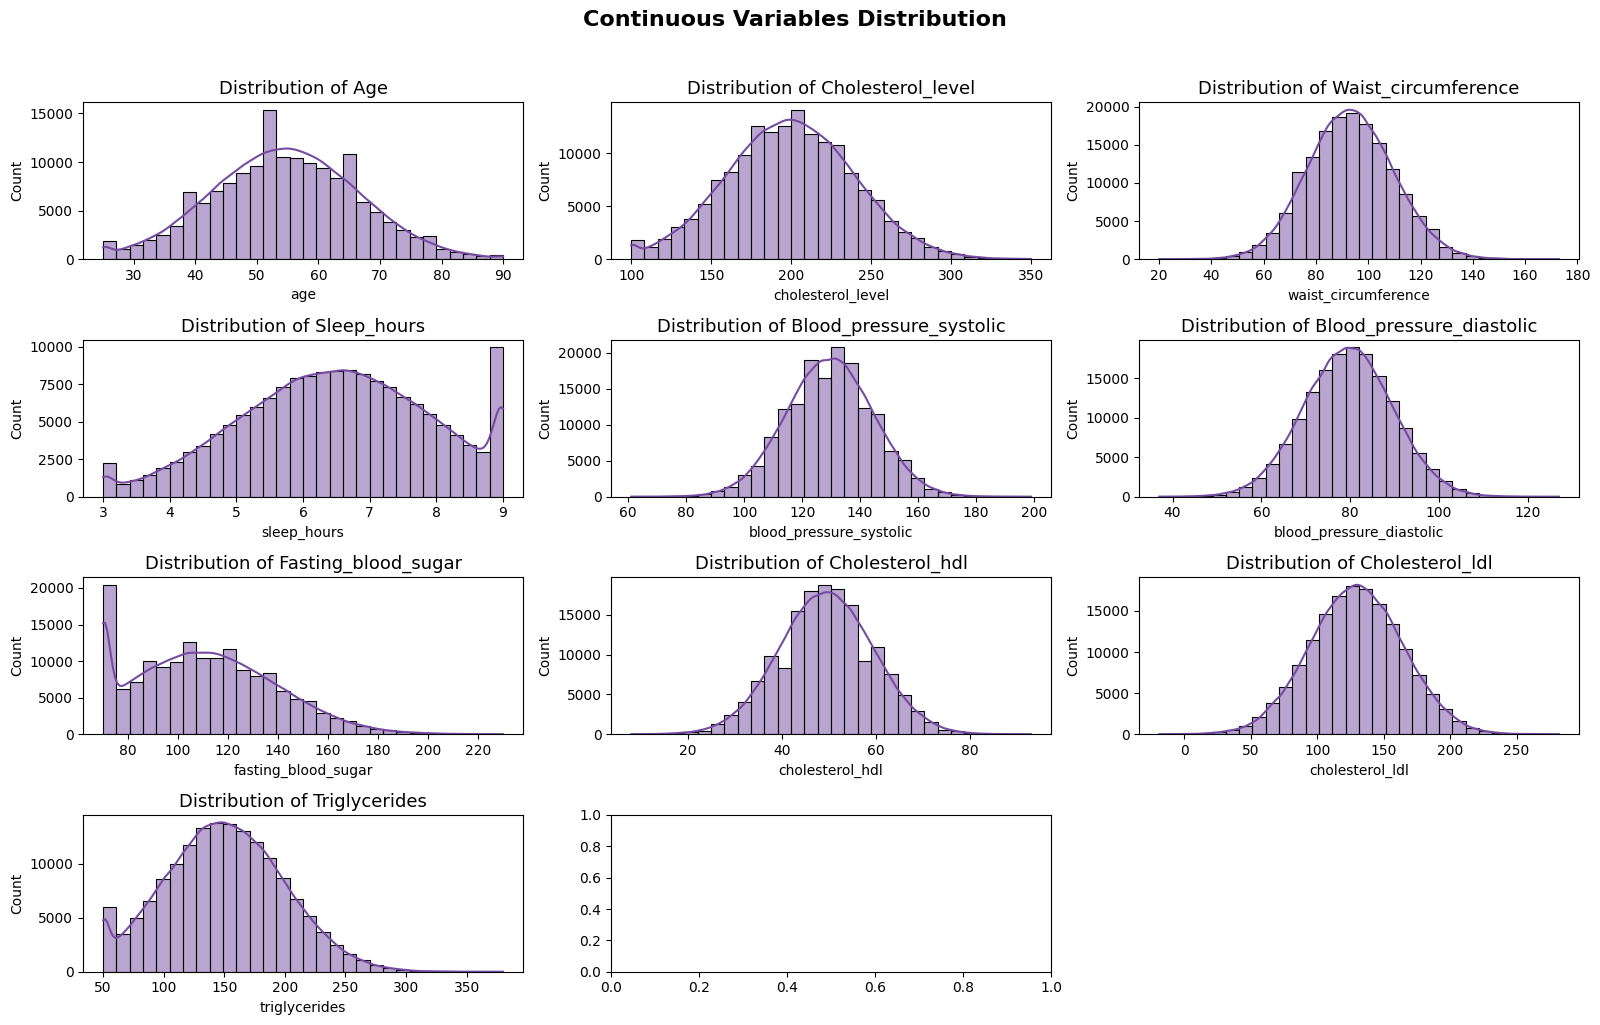

In [147]:
#distribution
# nums=df.select_dtypes(include=['int64','float64']).columns
nums=['age','cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(16, 10))
axes=ax.flatten()
for i, col in enumerate(nums):
    sns.histplot(df[col], bins=30, kde=True, color='#764ba2', ax=axes[i])
    plt.title(f'{col.capitalize()} Distribution', fontsize=14, fontweight='bold')
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
axes[-1].set_visible(False)
plt.suptitle('Continuous Variables Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [148]:
# why < -10? because the smallest value of LDL is 10. I tried to find a pattern to know if it's noise or important.
y = df.loc[df['cholesterol_ldl'] < -10, 'cholesterol_ldl']
y
#Few. it means it's noise data...

,cholesterol_ldl
18255,-13
44781,-18
46253,-19
66224,-15
119442,-16
148521,-13


In [149]:
(df['waist_circumference']<45).sum()

np.int64(169)

In [150]:
(df['cholesterol_ldl']<10).sum()

np.int64(50)

In [151]:
# ((df['waist_circumference']<45) | (df['cholesterol_ldl']<10)|(df['sleep_hours']<1)|(df['blood_pressure_systolic']<60)|(df['blood_pressure_diastolic'<30])|(df['cholesterol_level']<80)|(df['fasting_blood_sugar']<30)|(df['cholesterol_hdl']<5)|(df['triglycerides']<20)).sum()

((df['waist_circumference']<45) | (df['cholesterol_ldl']<10)).sum()


np.int64(219)

In [152]:
df.drop(df[(df['waist_circumference']<45) | (df['cholesterol_ldl']<10)].index, inplace=True)

In [153]:
df.drop('alcohol_consumption',axis=1,inplace=True)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158136 entries, 0 to 158354
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158136 non-null  int64  
 1   gender                          158136 non-null  object 
 2   region                          158136 non-null  object 
 3   income_level                    158136 non-null  object 
 4   hypertension                    158136 non-null  int64  
 5   diabetes                        158136 non-null  int64  
 6   cholesterol_level               158136 non-null  int64  
 7   obesity                         158136 non-null  int64  
 8   waist_circumference             158136 non-null  int64  
 9   family_history                  158136 non-null  int64  
 10  smoking_status                  158136 non-null  object 
 11  physical_activity               158136 non-null  object 
 12  dietary_habits       

In [155]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,158136.0,54.544569,11.911980,25.0,46.00000,55.000000,63.000000,90.0
hypertension,158136.0,0.299021,0.457831,0.0,0.00000,0.000000,1.000000,1.0
diabetes,158136.0,0.199828,0.399872,0.0,0.00000,0.000000,0.000000,1.0
cholesterol_level,158136.0,199.534110,39.740268,100.0,172.00000,199.000000,226.000000,350.0
obesity,158136.0,0.250190,0.433124,0.0,0.00000,0.000000,1.000000,1.0
waist_circumference,158136.0,93.326017,16.297834,45.0,82.00000,93.000000,104.000000,173.0
family_history,158136.0,0.300267,0.458375,0.0,0.00000,0.000000,1.000000,1.0
sleep_hours,158136.0,6.480361,1.425399,3.0,5.49316,6.507827,7.521005,9.0
blood_pressure_systolic,158136.0,129.515986,15.003515,61.0,119.00000,130.000000,140.000000,194.0
blood_pressure_diastolic,158136.0,79.491077,10.003726,37.0,73.00000,80.000000,86.000000,127.0


In [156]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[54, 56, 55, 52, 53, 57, 58, 51, 50, 59]",66,0,0.0,0
1,gender,object,"[Male, Female]",2,0,0.0,0
2,region,object,"[Urban, Rural]",2,0,0.0,0
3,income_level,object,"[Middle, Low, High]",3,0,0.0,0
4,hypertension,int64,"[0, 1]",2,0,0.0,0
5,diabetes,int64,"[0, 1]",2,0,0.0,0
6,cholesterol_level,int64,"[203, 199, 198, 196, 197, 201, 207, 195, 200, ...",247,0,0.0,0
7,obesity,int64,"[0, 1]",2,0,0.0,0
8,waist_circumference,int64,"[91, 94, 93, 96, 95, 92, 98, 89, 90, 97]",116,0,0.0,0
9,family_history,int64,"[0, 1]",2,0,0.0,0


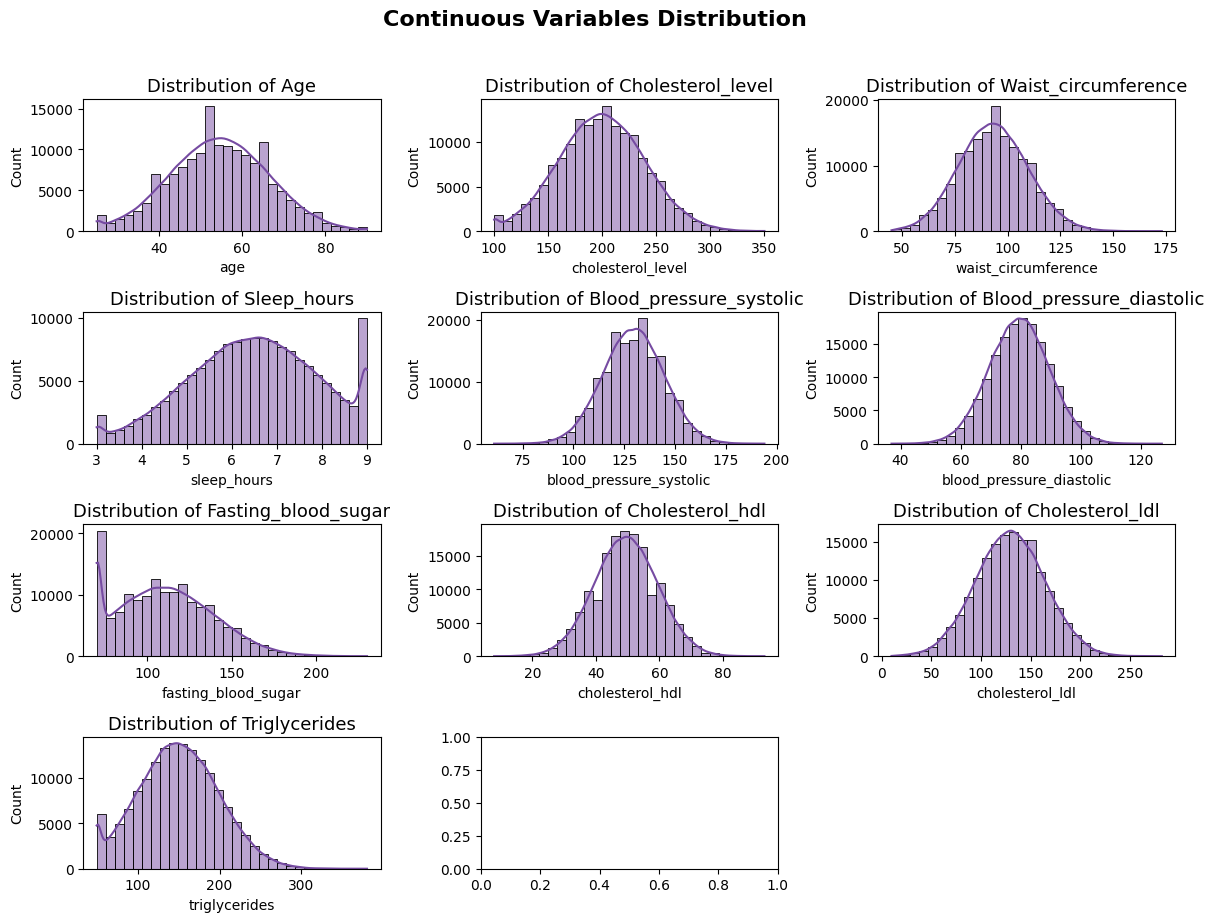

In [157]:
#distribution
# nums=df.select_dtypes(include=['int64','float64']).columns
nums=['age','cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 9))
axes=ax.flatten()
for i, col in enumerate(nums):
    sns.histplot(df[col], bins=30, kde=True, color='#764ba2', ax=axes[i])
    plt.title(f'{col.capitalize()} Distribution', fontsize=14, fontweight='bold')
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
axes[-1].set_visible(False)
plt.suptitle('Continuous Variables Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

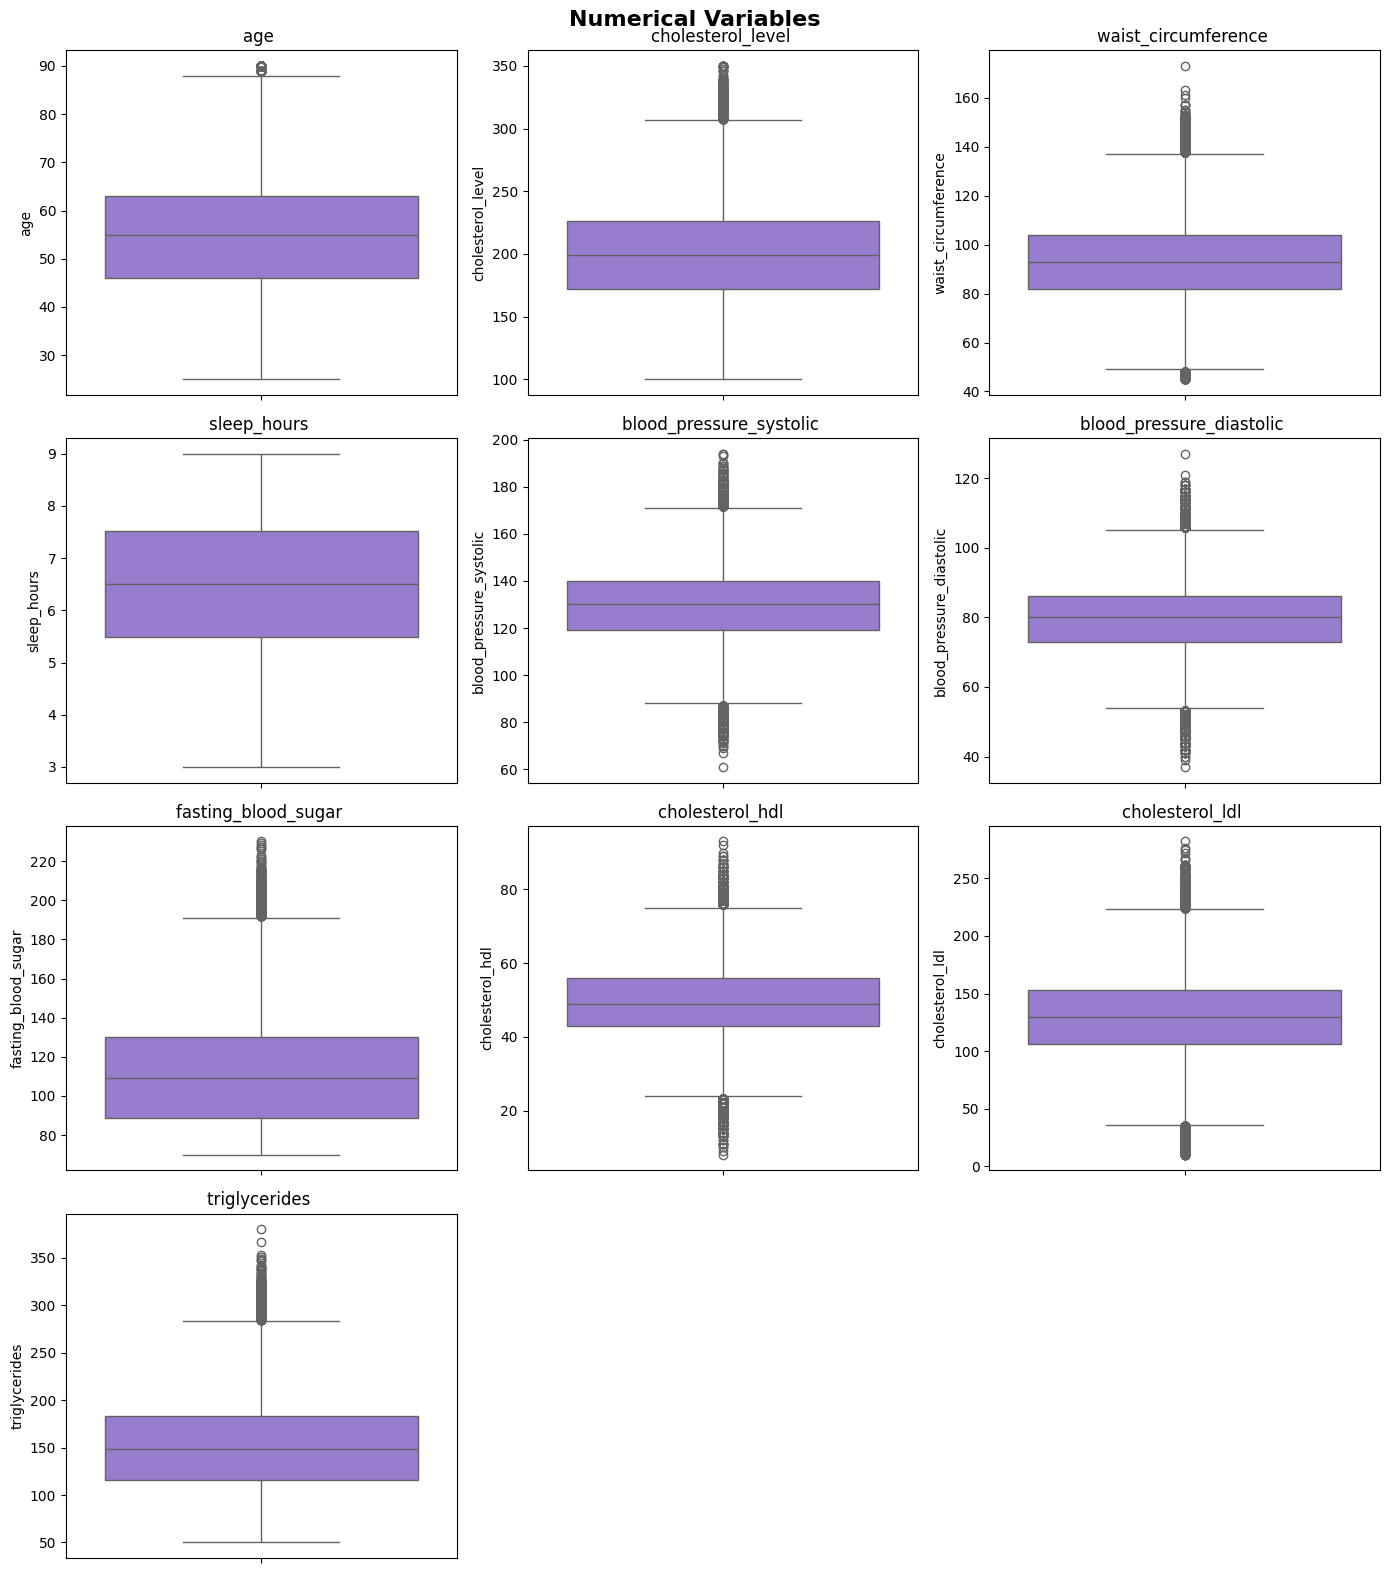

In [158]:
# nums=df.select_dtypes(include=['int64','float64']).columns
nums=['age','cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(nums):
    sns.boxplot(data=df, y=col, ax=axes[i],color='#9370DB')
    axes[i].set_title(f'{col} ', fontsize=12)
    axes[i].set_ylabel(col)

for j in range(len(nums), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [159]:
df[df['triglycerides']>367.0]

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
147902,60,Male,Urban,Middle,0,0,196,0,56,0,...,70,115,54,94,380,Abnormal,0,1,0,0


In [160]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[54, 56, 55, 52, 53, 57, 58, 51, 50, 59]",66,0,0.0,0
1,gender,object,"[Male, Female]",2,0,0.0,0
2,region,object,"[Urban, Rural]",2,0,0.0,0
3,income_level,object,"[Middle, Low, High]",3,0,0.0,0
4,hypertension,int64,"[0, 1]",2,0,0.0,0
5,diabetes,int64,"[0, 1]",2,0,0.0,0
6,cholesterol_level,int64,"[203, 199, 198, 196, 197, 201, 207, 195, 200, ...",247,0,0.0,0
7,obesity,int64,"[0, 1]",2,0,0.0,0
8,waist_circumference,int64,"[91, 94, 93, 96, 95, 92, 98, 89, 90, 97]",116,0,0.0,0
9,family_history,int64,"[0, 1]",2,0,0.0,0


##Feature Engneering


###**Additional clinical categories** (Asian / Indonesian context)
**```Age```**
| Category | Age Range (years) | Interpretation |
|---|---|---|
| Young Adult | 25–39 | Lower age-related risk, but metabolic abnormalities can still occur |
| Middle-aged Adult | 40–59 | Increasing prevalence of hypertension, diabetes, and dyslipidemia |
| Older Adult | 60–74 | Higher risk of cardiovascular and metabolic diseases |
| Elderly | 75–90 | Highest age-related risk and higher prevalence of chronic conditions |
---
**```Waist circumference```**
| Category | Value / Range | Interpretation |
|---|---|---|
| Lower risk | Men < 90 cm, Women < 80 cm | Lower metabolic risk |
| Increased risk | Men ≥ 90 cm, Women ≥ 80 cm | Increased risk of insulin resistance and metabolic syndrome |
| Severe obesity range | ≥ 120 cm | Very high abdominal obesity risk |
---
**```Blood pressure (Systolic)```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Optimal | < 120 mmHg | Optimal blood pressure |
| Normal | 120–129 mmHg | Normal range |
| High Normal | 130–139 mmHg | Above normal; lifestyle modification recommended |
| Grade 1 Hypertension | 140–159 mmHg | Mild hypertension |
| Grade 2 Hypertension | 160–179 mmHg | Moderate hypertension |
| Grade 3 Hypertension | ≥ 180 mmHg | Severe hypertension; critical clinical condition |
| Severe Hypotension | < 70 mmHg | Critical low pressure but survivable |
---
**```Blood pressure (Diastolic)```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Optimal | < 80 mmHg | Optimal diastolic pressure |
| Normal | 80–84 mmHg | Normal range |
| High Normal | 85–89 mmHg | Above normal; lifestyle modification recommended |
| Grade 1 Hypertension | 90–99 mmHg | Mild diastolic hypertension |
| Grade 2 Hypertension | 100–109 mmHg | Moderate diastolic hypertension |
| Grade 3 Hypertension | ≥ 110 mmHg | Severe diastolic hypertension |
| Severe Hypotension | < 40 mmHg | Critical low pressure but survivable |
---
**```Fasting blood sugar```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Normal | < 100 mg/dL | Normal glucose regulation |
| Prediabetes | 100–125 mg/dL | Increased diabetes risk |
| Diabetes range | ≥ 126 mg/dL | Diabetes-level fasting glucose |
| Severe hyperglycemia | ≥ 300 mg/dL | High-risk clinical condition |
| Extreme but survivable | 600–700 mg/dL | Reported in living patients |

---
**```Total cholesterol (cholesterol_level)```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Desirable | < 200 mg/dL | Lower cardiovascular risk |
| Borderline high | 200–239 mg/dL | Moderate risk |
| High | ≥ 240 mg/dL | Increased cardiovascular risk |
| Extreme | ≥ 400 mg/dL | Severe dyslipidemia |

---
**```LDL cholesterol```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Optimal | < 100 mg/dL | Preferred level |
| High | 160–189 mg/dL | Increased risk |
| Very high | ≥ 190 mg/dL | Severe LDL elevation |
---
**```HDL cholesterol```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Low risk | ≥ 40 mg/dL (men), ≥ 50 mg/dL (women) | Protective level |
| Low | < 40 mg/dL | Increased metabolic risk |
| Very low | < 20 mg/dL | Severe HDL deficiency |
---
**```Triglycerides```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Normal | < 150 mg/dL | Normal lipid level |
| High | 200–499 mg/dL | Increased cardiovascular risk |
| Very high | ≥ 500 mg/dL | High pancreatitis risk |
| Extreme | ≥ 1000 mg/dL | Severe hypertriglyceridemia |
---
**```Sleep Hours```**

| Category | Sleep Duration (hours/day) | Interpretation |
|---|---|---|
| Very Short Sleep | < 5 hours | Associated with higher metabolic and cardiovascular risk |
| Short Sleep | 5–6 hours | Slightly increased health risk in many studies |
| Recommended Range | 7–9 hours | Generally associated with better health outcomes in adults |
| Long Sleep | 10–12 hours | May be associated with increased health risks |
| Extreme Long Sleep | > 12 hours | Uncommon; may indicate underlying health conditions |
---
# References with Links

| Reference | Link |
|---|---|
| WHO Expert Consultation - Asian BMI and metabolic risk | https://doi.org/10.1016/S0140-6736(03)15268-3 |
| Alberti et al. Harmonizing Metabolic Syndrome | https://doi.org/10.1161/CIRCULATIONAHA.109.192644 |
| Indonesian Society of Hypertension (InaSH) Consensus 2019 | https://inash.or.id |
| American Diabetes Association Standards of Care | https://diabetesjournals.org/care |
| NCEP ATP III Report | https://www.nhlbi.nih.gov/files/docs/guidelines/atp3xsum.pdf |
| Berglund Hypertriglyceridemia Statement | https://doi.org/10.1161/CIR.0b013e3182160726 |
| Itani Sleep Meta-analysis | https://doi.org/10.1016/j.sleep.2017.05.015 |
| Riskesdas Indonesia | https://www.badankebijakan.kemkes.go.id |

In [161]:
df_copy=df.copy()

In [162]:
data_info(df_copy)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[54, 56, 55, 52, 53, 57, 58, 51, 50, 59]",66,0,0.0,0
1,gender,object,"[Male, Female]",2,0,0.0,0
2,region,object,"[Urban, Rural]",2,0,0.0,0
3,income_level,object,"[Middle, Low, High]",3,0,0.0,0
4,hypertension,int64,"[0, 1]",2,0,0.0,0
5,diabetes,int64,"[0, 1]",2,0,0.0,0
6,cholesterol_level,int64,"[203, 199, 198, 196, 197, 201, 207, 195, 200, ...",247,0,0.0,0
7,obesity,int64,"[0, 1]",2,0,0.0,0
8,waist_circumference,int64,"[91, 94, 93, 96, 95, 92, 98, 89, 90, 97]",116,0,0.0,0
9,family_history,int64,"[0, 1]",2,0,0.0,0


In [163]:
# =========================
# Age
# =========================
df['age_class'] = df['age'].apply(
    lambda x:
    'Young Adult' if 25 <= x <= 39 else
    'Middle-aged Adult' if 40 <= x <= 59 else
    'Older Adult' if 60 <= x <= 74 else
    'Elderly'
)


# =========================
# Waist circumference (Asian reference)
# =========================
def waist_risk(row):
    waist = row['waist_circumference']

    if row['gender'] == 'Male':
        if waist < 90:
            return 'Lower risk'
        elif waist < 120:
            return 'Increased risk'
        else:
            return 'Severe obesity range'

    elif row['gender'] == 'Female':
        if waist < 80:
            return 'Lower risk'
        elif waist < 120:
            return 'Increased risk'
        else:
            return 'Severe obesity range'

df['waist_class'] = df.apply(waist_risk, axis=1)


# =========================
# Systolic Blood Pressure
# =========================
df['bp_systolic_class'] = df['blood_pressure_systolic'].apply(
    lambda x:
    'Severe Hypotension' if x < 70 else
    'Optimal' if x < 120 else
    'Normal' if x <= 129 else
    'High Normal' if x <= 139 else
    'Grade 1 Hypertension' if x <= 159 else
    'Grade 2 Hypertension' if x <= 179 else
    'Grade 3 Hypertension'
)


# =========================
# Diastolic Blood Pressure
# =========================
df['bp_diastolic_class'] = df['blood_pressure_diastolic'].apply(
    lambda x:
    'Severe Hypotension' if x < 40 else
    'Optimal' if x < 80 else
    'Normal' if x <= 84 else
    'High Normal' if x <= 89 else
    'Grade 1 Hypertension' if x <= 99 else
    'Grade 2 Hypertension' if x <= 109 else
    'Grade 3 Hypertension'
)


# =========================
# Fasting Blood Sugar
# =========================
df['fasting_class'] = df['fasting_blood_sugar'].apply(
    lambda x:
    'Normal' if x < 100 else
    'Prediabetes' if x <= 125 else
    'Diabetes range' if x < 300 else
    'Severe hyperglycemia' if x < 600 else
    'Extreme but survivable'
)


# =========================
# Total Cholesterol
# =========================
df['cholesterol_class'] = df['cholesterol_level'].apply(
    lambda x:
    'Desirable' if x < 200 else
    'Borderline high' if x <= 239 else
    'High' if x < 400 else
    'Extreme'
)


# =========================
# LDL Cholesterol
# =========================
df['ldl_class'] = df['cholesterol_ldl'].apply(
    lambda x:
    'Optimal' if x < 100 else
    'High' if 160 <= x <= 189 else
    'Very high' if x >= 190 else
    'Intermediate'
)


# =========================
# HDL Cholesterol
# =========================
def hdl_category(row):

    hdl = row['cholesterol_hdl']

    if hdl < 20:
        return 'High risk'

    if row['gender'] == 'Male':
        return 'Low risk' if hdl >= 40 else 'Moderate risk'

    elif row['gender'] == 'Female':
        return 'Low risk' if hdl >= 50 else 'Moderate risk'


df['hdl_class'] = df.apply(hdl_category, axis=1)


# =========================
# Triglycerides
# =========================
df['triglycerides_class'] = df['triglycerides'].apply(
    lambda x:
    'Normal' if x < 150 else
    'High' if x <= 499 else
    'Very high' if x < 1000 else
    'Extreme'
)


# =========================
# Sleep Hours
# =========================
df['sleep_class'] = df['sleep_hours'].apply(
    lambda x:
    'Very Short Sleep' if x < 5 else
    'Short Sleep' if x <= 6 else
    'Recommended Range' if x <= 9 else
    'Long Sleep' if x <= 12 else
    'Extreme Long Sleep'
)

##**More Features**
|Feature Name|Description|
|------------|-----------|
|Risk Score|Scoring the risks|
|Metabolic Syndrome|Increased abdominal fat, high blood pressure, high blood sugar, and high triglycerides. The combination of these problems **doubles the risk of heart disease**, stroke, and type 2 diabetes.|
|Lifestyle Score|Scoring how good is your lifestyle|
|tg hdl ratio|This ratio is used to assess the risk of metabolic syndrome, insulin resistance, and cardiovascular disease.|
|Pulse pressure|This number represents the force with which your heart pumps blood with each beat.|


In [164]:
#scoring the risk
df['risk_score'] = (
    df['hypertension'] +
    df['diabetes'] +
    df['obesity'] +
    df['smoking_status'].map({'Never':0, 'Past':1, 'Current':2}) +
    (df['ldl_class'].isin(['High','Very High'])).astype(int) +
    (df['hdl_class'] != 'Low risk').astype(int)
)

#Increased abdominal fat, high blood pressure, high blood sugar, and high triglycerides. The combination of these problems doubles the risk of heart disease, stroke, and type 2 diabetes.
df['metabolic_syndrome'] = (
    (df['waist_class'] != 'Lower risk').astype(int) +
    (df['triglycerides_class'] != 'Normal').astype(int) +
    (df['hdl_class'] != 'Low risk').astype(int) +
    (df['hypertension'] == 1).astype(int) +
    (df['fasting_class'] != 'Normal').astype(int)
    >= 3
).astype(int)


#score of how good lifestyle
df['lifestyle_score'] = (
    df['physical_activity'].map({'Low':0, 'Moderate':1, 'High':2}) +
    df['dietary_habits'].map({'Unhealthy':0, 'Healthy':1}) +
    df['sleep_class'].map({
        'Very Short Sleep':0,
        'Short Sleep':1,
        'Recommended Range':2
    })
)

#This ratio is used to assess the risk of metabolic syndrome, insulin resistance, and cardiovascular disease.
df['tg_hdl_ratio'] = df['triglycerides'] / df['cholesterol_hdl']
#This number represents the force with which your heart pumps blood with each beat.
df['pulse_pressure'] = (
    df['blood_pressure_systolic'] - df['blood_pressure_diastolic']
)

In [165]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[54, 56, 55, 52, 53, 57, 58, 51, 50, 59]",66,0,0.0,0
1,gender,object,"[Male, Female]",2,0,0.0,0
2,region,object,"[Urban, Rural]",2,0,0.0,0
3,income_level,object,"[Middle, Low, High]",3,0,0.0,0
4,hypertension,int64,"[0, 1]",2,0,0.0,0
5,diabetes,int64,"[0, 1]",2,0,0.0,0
6,cholesterol_level,int64,"[203, 199, 198, 196, 197, 201, 207, 195, 200, ...",247,0,0.0,0
7,obesity,int64,"[0, 1]",2,0,0.0,0
8,waist_circumference,int64,"[91, 94, 93, 96, 95, 92, 98, 89, 90, 97]",116,0,0.0,0
9,family_history,int64,"[0, 1]",2,0,0.0,0


In [166]:
# df.drop(['stress_risk',
# 'heart_risk_group',
# 'diabetes_obesity',
# 'smoking_stress'
# ],axis=1,inplace=True)

## **Statistics**

### Notes

When analyzed individually, `smoking_status` showed the strongest
association with heart attack (ANOVA F=3166, Chi²=4618).

However, when all variables were considered simultaneously,
`previous_heart_disease` and `hypertension` emerged as the most
important predictors (XGBoost importance ≈ 0.17 each).

This suggests that smoking is strongly associated with heart attack
on its own, whereas previous heart disease and hypertension provide
more predictive information after accounting for the presence of
other risk factors.

Across statistical tests (Chi-square, ANOVA, Odds Ratio,
Point-Biserial correlation) and machine-learning models
(Random Forest and XGBoost), `hypertension`,
`previous_heart_disease`, `diabetes`, and `smoking_status`
were consistently identified as the most influential risk factors.

---
**Tier 1 (Strong & Consistent)**
- `previous_heart_disease`
- `hypertension`
- `smoking_status`
- `diabetes`
- `risk_score`
- `cholesterol_level`

**Tier 2 (Meaningful Predictors)**

- `obesity`
- `fasting_blood_sugar`
- `age`
- `metabolic_syndrome`
- `tg_hdl_ratio`

**Tier 3 (Weak or Inconsistent)**
- `family_history`
- `medication_usage`
- `stress_level`
- `income_level`
- `physical_activity`
- `participated_in_free_screening`

In [235]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr, pointbiserialr
import pandas as pd

y = df['heart_attack']


cats = ['gender','income_level', 'region' ,'smoking_status',
        'dietary_habits','physical_activity',
        'air_pollution_exposure','stress_level','EKG_results',
        'age_class', 'waist_class', 'bp_systolic_class', 'bp_diastolic_class',
        'fasting_class', 'cholesterol_class', 'ldl_class', 'hdl_class',
        'triglycerides_class', 'sleep_class']

nums = ['age', 'waist_circumference', 'cholesterol_level', 'sleep_hours',
        'blood_pressure_systolic', 'blood_pressure_diastolic',
        'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl',
        'triglycerides','risk_score', 'lifestyle_score',
        'tg_hdl_ratio', 'pulse_pressure']

binary = [ 'hypertension', 'diabetes', 'obesity', 'family_history',
           'previous_heart_disease', 'medication_usage',
           'participated_in_free_screening','metabolic_syndrome']
# df[binary] = df[binary].astype('int')
# ============================================================
#  ANOVA — categorical vs target
# ============================================================
cats_encoded = df[cats].apply(LabelEncoder().fit_transform)
f_values, p_values = f_classif(cats_encoded, y)

anova_df = pd.DataFrame({
    'Feature': cats,
    'F-Score': f_values,
    'P-Value': p_values
}).sort_values(by='F-Score', ascending=False)

print("=" * 50)
print("      Categorical Features vs Heart Attack")
print("=" * 50)
print(anova_df.to_string(index=False))

# ============================================================
#  Pearson — numerical vs target
# ============================================================
rs, pvals = [], []

for col in nums:
    r, pval = pearsonr(df[col], y)
    rs.append(r)
    pvals.append(pval)

pearson_df = pd.DataFrame({
    'Feature': nums,
    'Pearson_r': rs,
    'P-Value': pvals
}).sort_values(by='Pearson_r', ascending=False)

print("\n" + "=" * 50)
print("      Numerical Features vs Heart Attack")
print("=" * 50)
print(pearson_df.to_string(index=False))

# ============================================================
#  Point-Biserial — binary vs target
# ============================================================
rhos, pvals = [], []

for col in binary:
    r, pval = pointbiserialr(df[col], y)
    rhos.append(r)
    pvals.append(pval)

pb_df = pd.DataFrame({
    'Feature': binary,
    'PointBiserial_r': rhos,
    'P-Value': pvals
}).sort_values(by='PointBiserial_r', ascending=False)

print("\n" + "=" * 50)
print("      Binary Features vs Heart Attack")
print("=" * 50)
print(pb_df.to_string(index=False))

      Categorical Features vs Heart Attack
               Feature     F-Score      P-Value
        smoking_status 3166.077387 0.000000e+00
     cholesterol_class 1728.972661 0.000000e+00
         fasting_class  303.136253 7.905435e-68
             age_class  154.293742 2.075300e-35
                region    5.012540 2.516575e-02
        dietary_habits    4.450015 3.490251e-02
air_pollution_exposure    2.359273 1.245422e-01
                gender    1.981015 1.592855e-01
          stress_level    1.912567 1.666804e-01
           sleep_class    1.659436 1.976813e-01
           EKG_results    1.109043 2.922918e-01
             ldl_class    0.798695 3.714852e-01
          income_level    0.553729 4.567992e-01
           waist_class    0.510448 4.749461e-01
   triglycerides_class    0.179514 6.717921e-01
     bp_systolic_class    0.088724 7.658055e-01
    bp_diastolic_class    0.078419 7.794520e-01
     physical_activity    0.053457 8.171545e-01
             hdl_class    0.002266 9.620354e-

In [236]:
#more catigorical corolation:
from scipy.stats import chi2_contingency

results = []

for col in cats:
    contingency = pd.crosstab(df[col], df['heart_attack'])
    chi2, p, dof, exp = chi2_contingency(contingency)

    results.append([col, chi2, p])

chi_df = pd.DataFrame(
    results,
    columns=['Feature','Chi2','PValue']
).sort_values('Chi2', ascending=False)

print(chi_df)

                   Feature         Chi2         PValue
3           smoking_status  4618.039708   0.000000e+00
14       cholesterol_class  3002.088813   0.000000e+00
9                age_class  2719.131523   0.000000e+00
10             waist_class   567.274392  6.575531e-124
13           fasting_class   456.534257  7.325643e-100
12      bp_diastolic_class     9.608942   1.421159e-01
2                   region     4.988380   2.551809e-02
6   air_pollution_exposure     4.783460   9.147129e-02
4           dietary_habits     4.427878   3.535644e-02
11       bp_systolic_class     3.865270   6.949031e-01
5        physical_activity     3.656720   1.606769e-01
7             stress_level     3.283872   1.936049e-01
18             sleep_class     2.591289   2.737214e-01
0                   gender     1.966588   1.608105e-01
16               hdl_class     1.648262   4.386159e-01
8              EKG_results     1.095544   2.952460e-01
15               ldl_class     1.043494   7.907294e-01
1         

In [237]:
for col in binary:
    ct = pd.crosstab(df[col], df['heart_attack'])

    try:
        OR = (
            ct.loc[1,1] * ct.loc[0,0]
        ) / (
            ct.loc[1,0] * ct.loc[0,1]
        )

        print(f"{col}: {OR:.3f}")

    except Exception as e:
        print(f"{col}: {e}")

hypertension: 3.307
diabetes: 2.653
obesity: 2.216
family_history: 1.006
previous_heart_disease: 4.051
medication_usage: 1.019
participated_in_free_screening: 0.985
metabolic_syndrome: 1.616


In [238]:
from sklearn.ensemble import RandomForestClassifier

# كل الـ Features
X = df.drop('heart_attack', axis=1)
y = df['heart_attack']

# Encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_encoded, y)

importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(20))

                     Feature  Importance
14    previous_heart_disease    0.069353
17                risk_score    0.053095
3          cholesterol_level    0.052362
1               hypertension    0.049599
10       fasting_blood_sugar    0.048432
0                        age    0.045491
20              tg_hdl_ratio    0.044315
7                sleep_hours    0.044210
12           cholesterol_ldl    0.044114
13             triglycerides    0.042168
5        waist_circumference    0.040725
21            pulse_pressure    0.039384
8    blood_pressure_systolic    0.038309
11           cholesterol_hdl    0.038189
9   blood_pressure_diastolic    0.037501
2                   diabetes    0.026242
4                    obesity    0.018335
19           lifestyle_score    0.018121
56    cholesterol_class_High    0.009154
26      smoking_status_Never    0.008162


In [239]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_encoded, y)

xgb_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print(xgb_importance.head(20))

                                    Feature  Importance
14                   previous_heart_disease    0.174215
1                              hypertension    0.171545
17                               risk_score    0.125989
2                                  diabetes    0.082635
4                                   obesity    0.079579
27                      smoking_status_Past    0.048986
0                                       age    0.041743
26                     smoking_status_Never    0.040444
3                         cholesterol_level    0.037821
60                       hdl_class_Low risk    0.031747
10                      fasting_blood_sugar    0.031422
61                  hdl_class_Moderate risk    0.007435
12                          cholesterol_ldl    0.006492
41   bp_systolic_class_Grade 2 Hypertension    0.005437
47  bp_diastolic_class_Grade 2 Hypertension    0.005381
57                   ldl_class_Intermediate    0.005087
36              age_class_Middle-aged Adult    0

#Visualization

## **General Overview**

Note:
>it's not balanced.

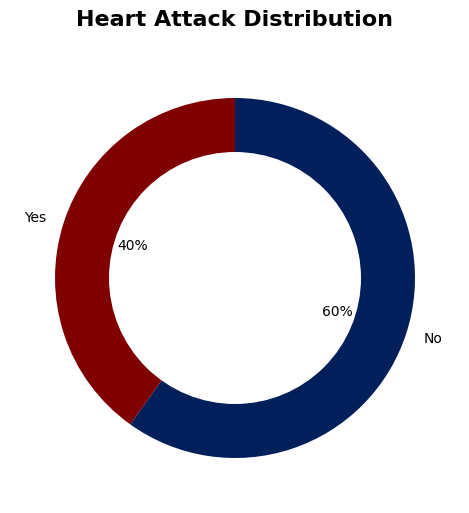

In [172]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
plt.pie(y.value_counts().values, labels=y.value_counts().index, autopct='%1.0f%%', startangle=90, counterclock=False,colors=['#001F5B','#800000'])
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.tight_layout()
plt.title('Heart Attack Distribution', fontsize=16, fontweight='bold', pad=20)
plt.show()

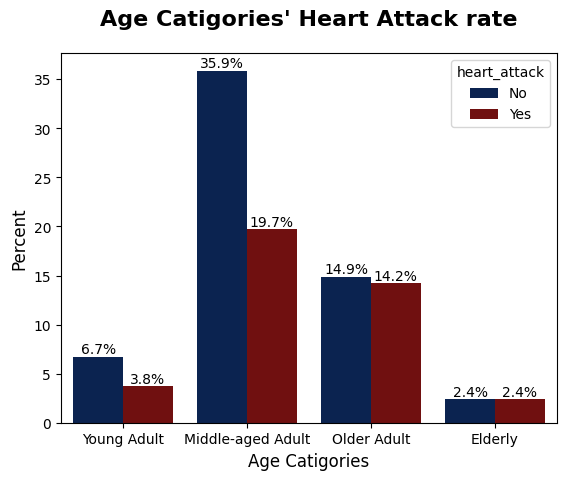

In [173]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
ax=sns.countplot(data=df,x='age_class',palette=['#001F5B','#800000'],hue=y,stat='percent',order=['Young Adult', 'Middle-aged Adult', 'Older Adult', 'Elderly'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Age Catigories\' Heart Attack rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age Catigories', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

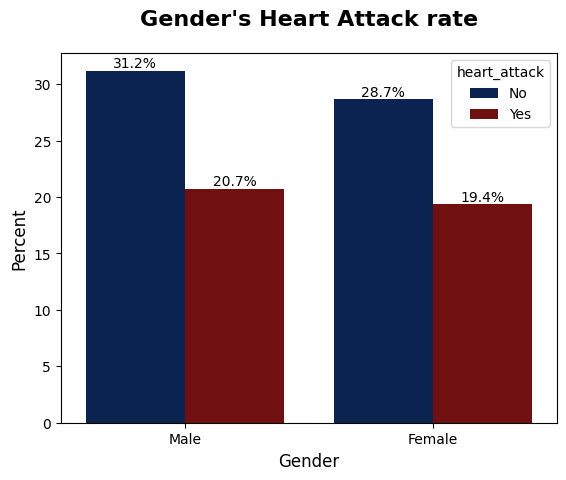

In [174]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
ax=sns.countplot(data=df,x='gender',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Gender\'s Heart Attack rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

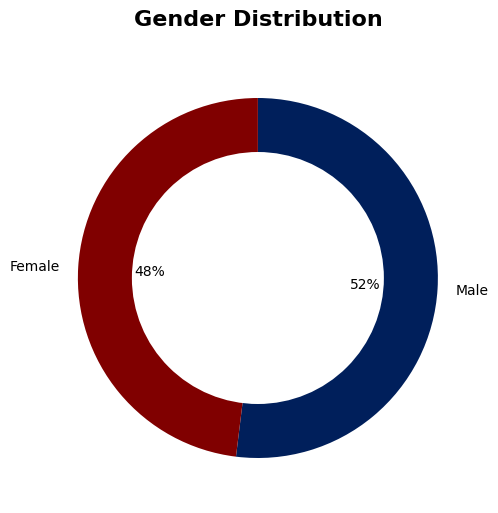

In [175]:
plt.pie(df['gender'].value_counts().values, labels=df['gender'].value_counts().index, autopct='%1.0f%%', startangle=90, counterclock=False,colors=['#001F5B','#800000'])
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.tight_layout()
plt.title('Gender Distribution', fontsize=16, fontweight='bold', pad=20)
plt.show()

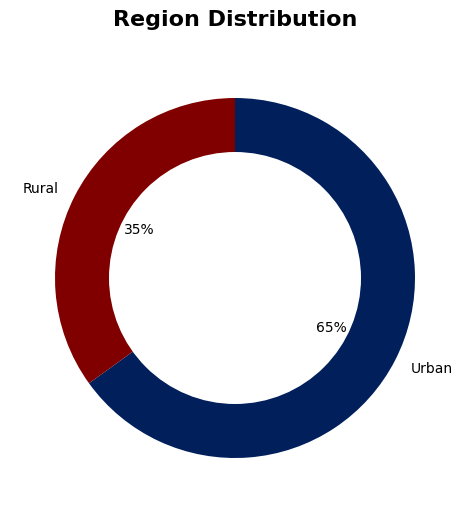

In [176]:
plt.pie(df['region'].value_counts().values, labels=df['region'].value_counts().index, autopct='%1.0f%%', startangle=90, counterclock=False,colors=['#001F5B','#800000'])
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.tight_layout()
plt.title('Region Distribution', fontsize=16, fontweight='bold', pad=20)
plt.show()

## **Lab Results**

In [177]:
df.select_dtypes(include='object').columns

Index(['gender', 'region', 'income_level', 'smoking_status',
       'physical_activity', 'dietary_habits', 'air_pollution_exposure',
       'stress_level', 'EKG_results', 'age_class', 'waist_class',
       'bp_systolic_class', 'bp_diastolic_class', 'fasting_class',
       'cholesterol_class', 'ldl_class', 'hdl_class', 'triglycerides_class',
       'sleep_class'],
      dtype='object')

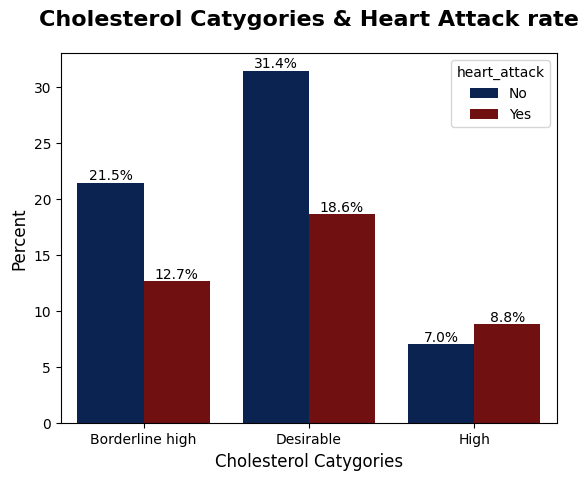

In [178]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
ax=sns.countplot(data=df,x='cholesterol_class',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Cholesterol Catygories & Heart Attack rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cholesterol Catygories', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

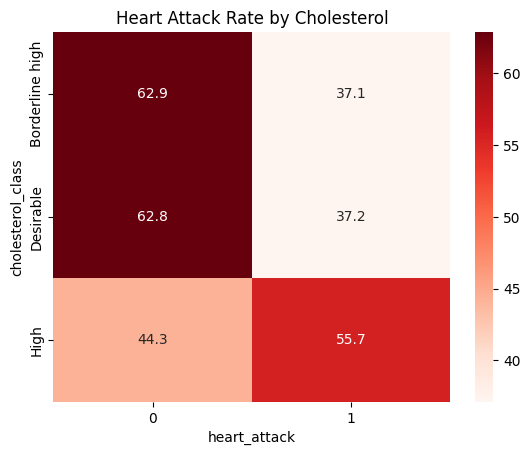

In [179]:
ct = pd.crosstab(
    df['cholesterol_class'],
    df['heart_attack'],
    normalize='index'
) * 100

sns.heatmap(
    ct,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Heart Attack Rate by Cholesterol')
plt.show()

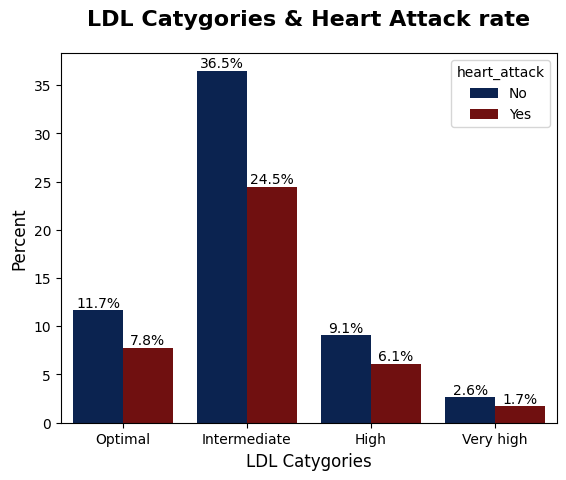

In [180]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
ax=sns.countplot(data=df,x='ldl_class',palette=['#001F5B','#800000'],hue=y,stat='percent',order=['Optimal','Intermediate','High','Very high'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('LDL Catygories & Heart Attack rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('LDL Catygories', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

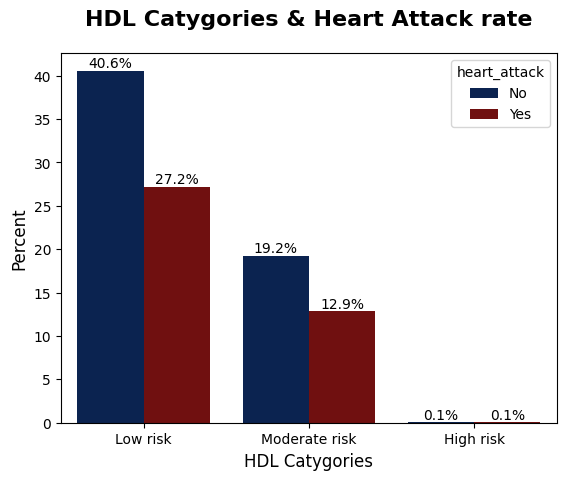

In [181]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
ax=sns.countplot(data=df,x='hdl_class',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('HDL Catygories & Heart Attack rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('HDL Catygories', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

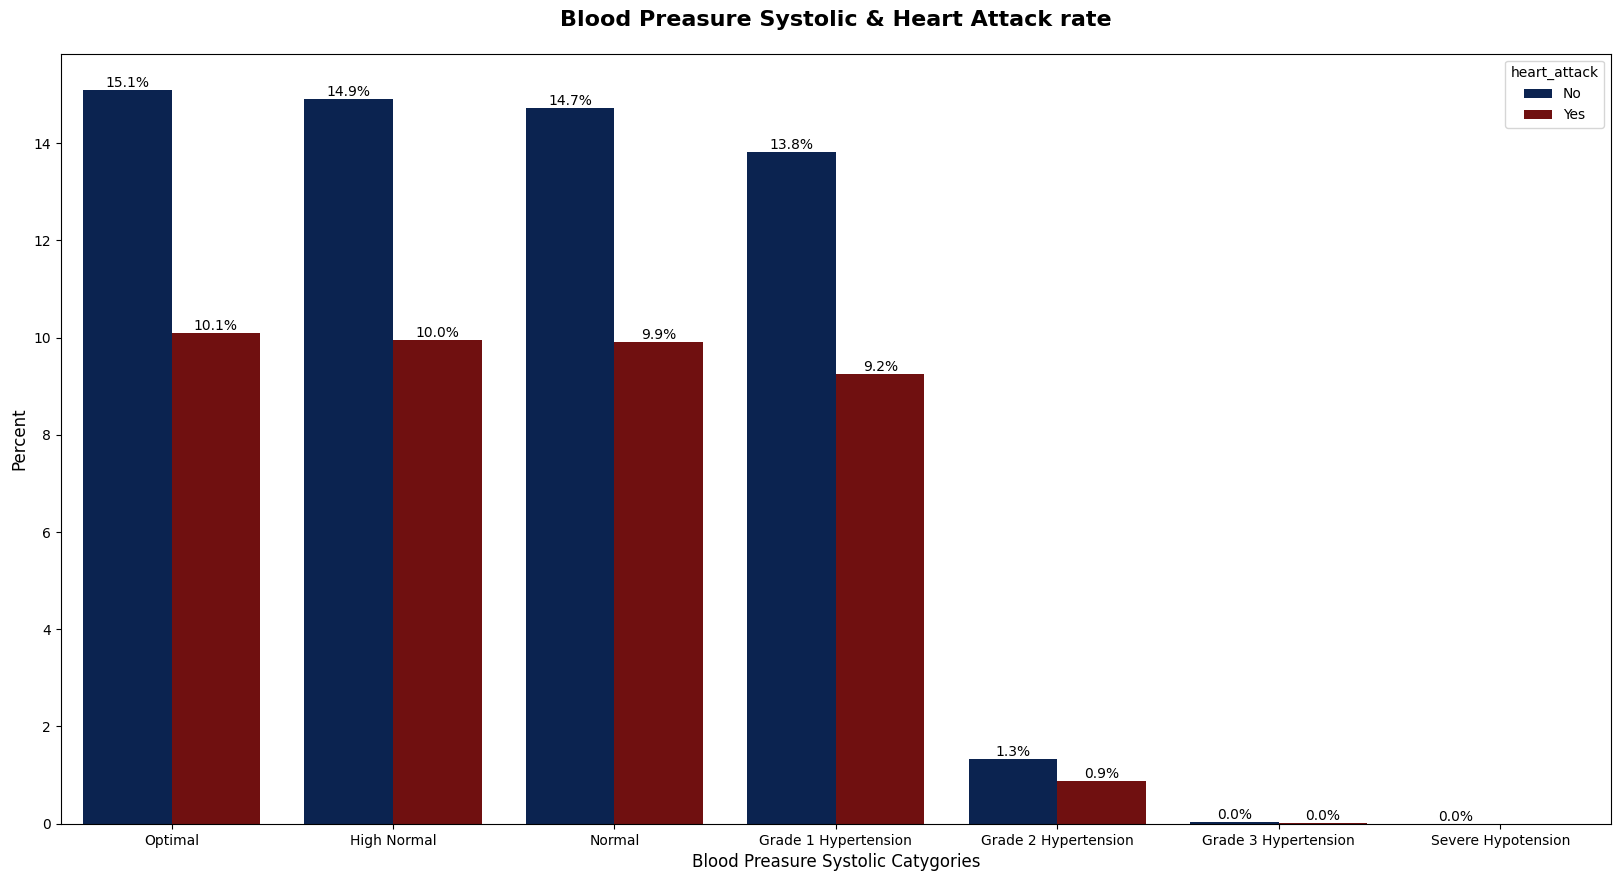

In [182]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
plt.figure(figsize=(20,10))
ax=sns.countplot(data=df,x='bp_systolic_class',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Blood Preasure Systolic & Heart Attack rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Blood Preasure Systolic Catygories', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

In [183]:
df['bp_systolic_class'].value_counts()

,count
bp_systolic_class,
Optimal,39829
High Normal,39307
Normal,38955
Grade 1 Hypertension,36482
Grade 2 Hypertension,3485
Grade 3 Hypertension,75
Severe Hypotension,3


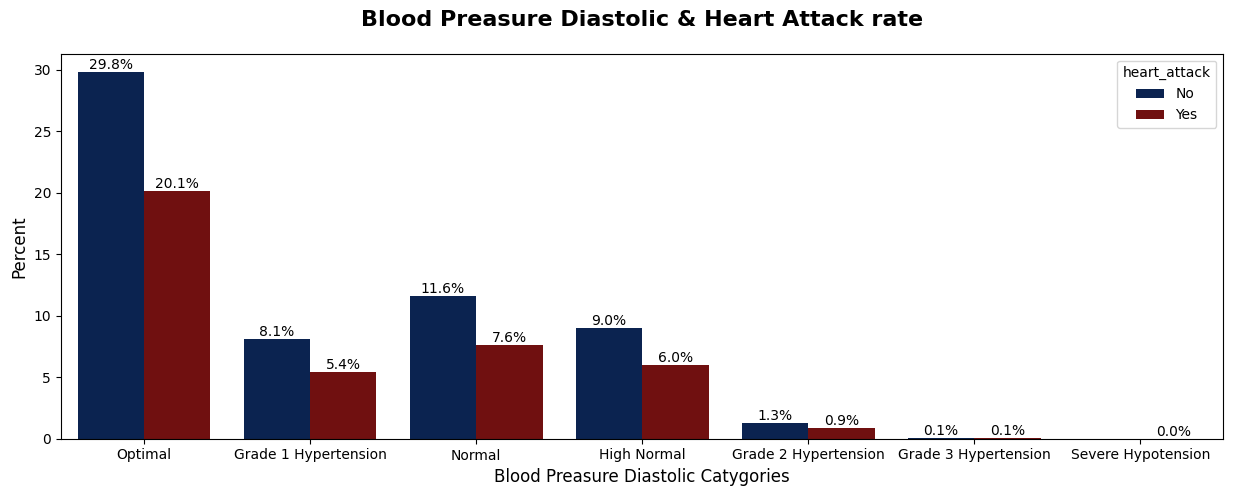

In [184]:
#'bp_diastolic_class'
y=df['heart_attack'].map({1:'Yes',0:'No'})
plt.figure(figsize=(15,5))
ax=sns.countplot(data=df,x='bp_diastolic_class',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Blood Preasure Diastolic & Heart Attack rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Blood Preasure Diastolic Catygories', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

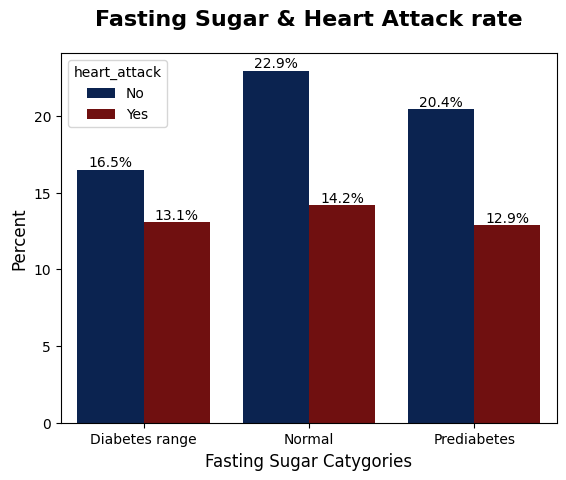

In [185]:
#'fasting_class'
y=df['heart_attack'].map({1:'Yes',0:'No'})
# plt.figure(figsize=(20,10))
ax=sns.countplot(data=df,x='fasting_class',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Fasting Sugar & Heart Attack rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fasting Sugar Catygories', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

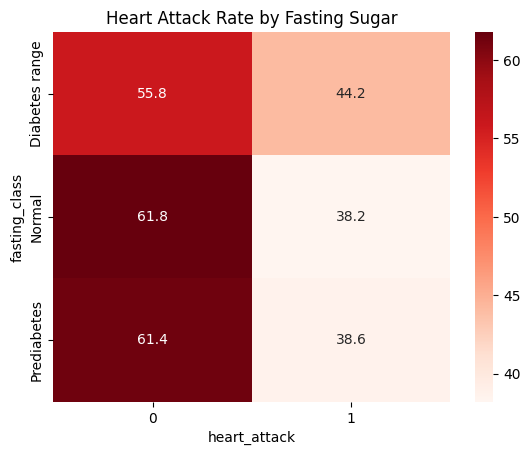

In [186]:
ct = pd.crosstab(
    df['fasting_class'],
    df['heart_attack'],
    normalize='index'
) * 100

sns.heatmap(
    ct,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Heart Attack Rate by Fasting Sugar')
plt.show()

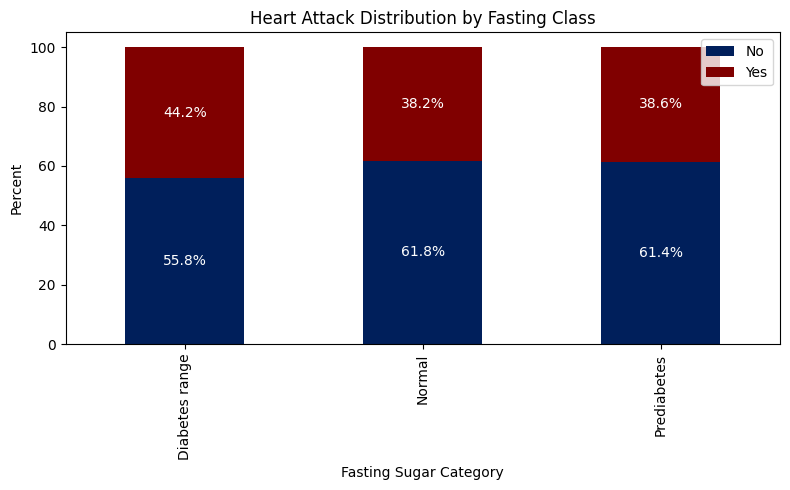

In [187]:
ct = pd.crosstab(
    df['fasting_class'],
    df['heart_attack'],
    normalize='index'
) * 100

ax = ct.plot(
    kind='bar',
    stacked=True,
    color=['#001F5B', '#800000'],
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        color='white',
        fontsize=10
    )

plt.ylabel('Percent')
plt.xlabel('Fasting Sugar Category')
plt.title('Heart Attack Distribution by Fasting Class')
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

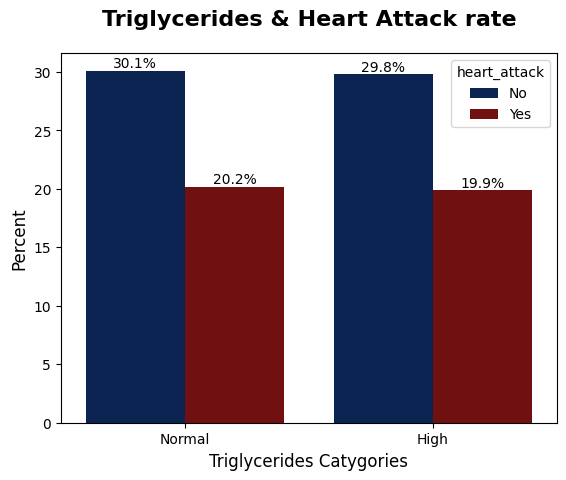

In [188]:
#'triglycerides_class'
y=df['heart_attack'].map({1:'Yes',0:'No'})
# plt.figure(figsize=(20,10))
ax=sns.countplot(data=df,x='triglycerides_class',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Triglycerides & Heart Attack rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Triglycerides Catygories', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

## **Medical & Clinical**

In [189]:
# #Hypertension/Diabetes/Obesity vs Heart Attack
# Previous Heart Disease vs Heart Attack
# Metabolic Syndrome vs Heart Attack
# Odds Ratio Chart

In [190]:
df.columns

Index(['age', 'gender', 'region', 'income_level', 'hypertension', 'diabetes',
       'cholesterol_level', 'obesity', 'waist_circumference', 'family_history',
       'smoking_status', 'physical_activity', 'dietary_habits',
       'air_pollution_exposure', 'stress_level', 'sleep_hours',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl',
       'triglycerides', 'EKG_results', 'previous_heart_disease',
       'medication_usage', 'participated_in_free_screening', 'heart_attack',
       'age_class', 'waist_class', 'bp_systolic_class', 'bp_diastolic_class',
       'fasting_class', 'cholesterol_class', 'ldl_class', 'hdl_class',
       'triglycerides_class', 'sleep_class', 'risk_score',
       'metabolic_syndrome', 'lifestyle_score', 'tg_hdl_ratio',
       'pulse_pressure'],
      dtype='object')

In [191]:
df['previous_heart_disease'].value_counts()

,count
previous_heart_disease,
0,126415
1,31721


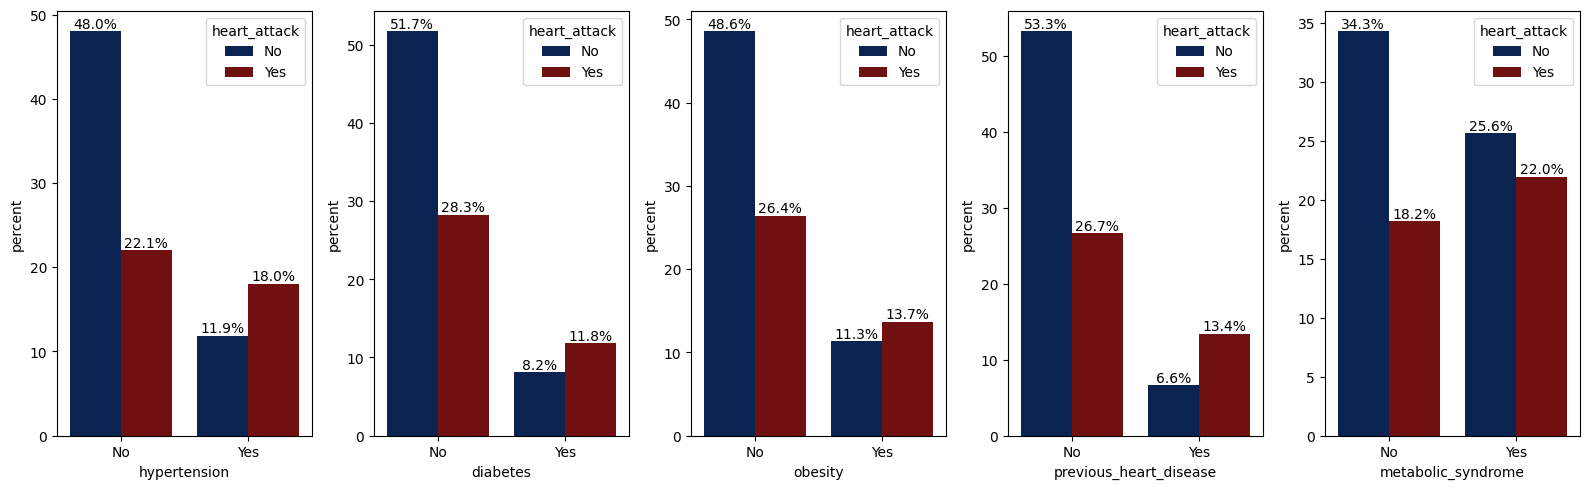

In [192]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
cols=['hypertension', 'diabetes','obesity','previous_heart_disease','metabolic_syndrome']
fig,axes=plt.subplots(1,5,figsize=(16,5))
axes=axes.flatten()
for i,col in enumerate(cols):
    map_col=df[col].map({1:'Yes',0:'No'})
    a=sns.countplot(data=df,x=map_col, hue=y, ax=axes[i], palette=['#001F5B','#800000'],stat='percent',order=['No','Yes'])
    for container in a.containers:
      a.bar_label(container, fmt='%.1f%%', fontsize=10)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

## **Lifestyle & Habits**

Note:
> the majority of people with current ``smoking_state`` are more at risk of heart attack

In [193]:
# Smoking Status vs Heart Attack
# Sleep Class vs Heart Attack
# Physical Activity vs Heart Attack
# Dietary Habits vs Heart Attack
# Stress Level vs Heart Attack

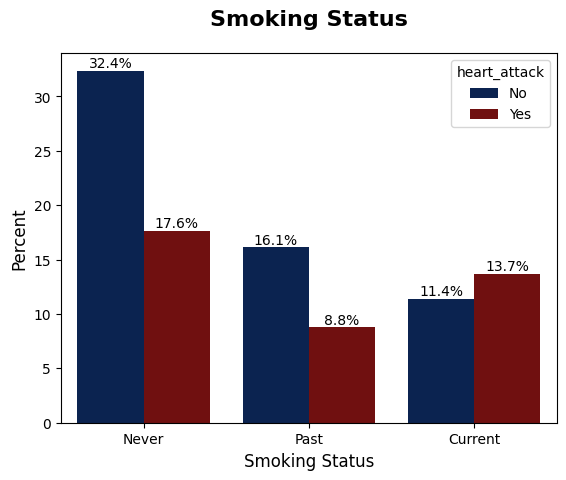

In [194]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
ax=sns.countplot(data=df,x='smoking_status',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Smoking Status', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

In [195]:
df.select_dtypes(include='object').columns

Index(['gender', 'region', 'income_level', 'smoking_status',
       'physical_activity', 'dietary_habits', 'air_pollution_exposure',
       'stress_level', 'EKG_results', 'age_class', 'waist_class',
       'bp_systolic_class', 'bp_diastolic_class', 'fasting_class',
       'cholesterol_class', 'ldl_class', 'hdl_class', 'triglycerides_class',
       'sleep_class'],
      dtype='object')

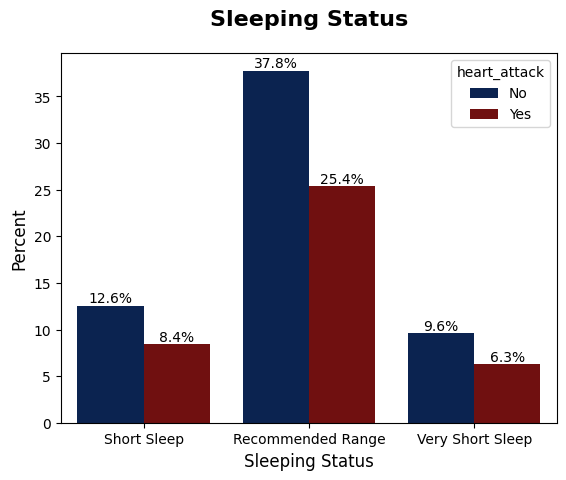

In [196]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
ax=sns.countplot(data=df,x='sleep_class',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Sleeping Status', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Sleeping Status', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

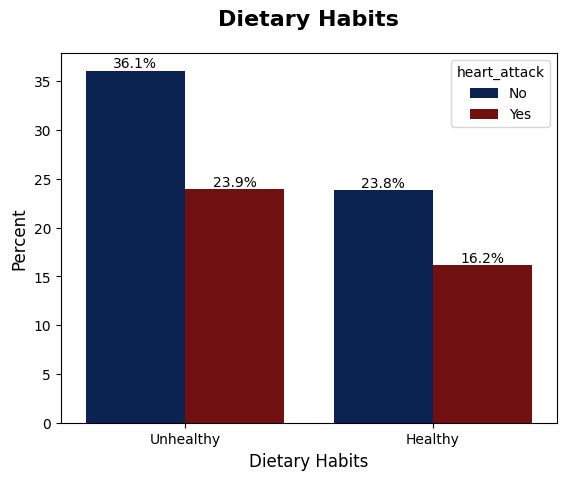

In [197]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
ax=sns.countplot(data=df,x='dietary_habits',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Dietary Habits', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Dietary Habits', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

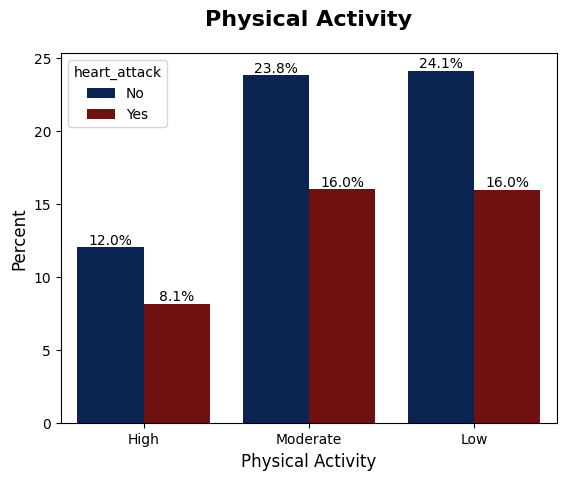

In [198]:
y=df['heart_attack'].map({1:'Yes',0:'No'})
ax=sns.countplot(data=df,x='physical_activity',palette=['#001F5B','#800000'],hue=y,stat='percent')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
plt.title('Physical Activity', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Physical Activity', fontsize=12)
plt.ylabel('Percent', fontsize=12)
plt.show()

In [199]:
df.groupby('heart_attack')['physical_activity'].value_counts()

heart_attack  physical_activity
0             Low                  38105
              Moderate             37631
              High                 18978
1             Moderate             25314
              Low                  25228
              High                 12880
Name: count, dtype: int64

#ML

####data importing

In [246]:
df_ml = pd.read_csv('/content/drive/MyDrive/heart_attack_prediction_indonesia.csv')

In [247]:
df_ml.shape

(158355, 28)

####preprosscing & feature engneering

In [248]:
df_ml.drop(df_ml[(df_ml['waist_circumference']<45) | (df_ml['cholesterol_ldl']<10)].index, inplace=True)
df_ml.drop('alcohol_consumption',axis=1,inplace=True)

In [249]:
df_ml_copy=df_ml.copy()
df_ml_copy2=df_ml.copy()

In [250]:
# =========================
# Age
# =========================
df_ml_copy['age_class'] = df_ml_copy['age'].apply(
    lambda x:
    'Young Adult' if 25 <= x <= 39 else
    'Middle-aged Adult' if 40 <= x <= 59 else
    'Older Adult' if 60 <= x <= 74 else
    'Elderly'
)

# =========================
# Waist circumference (Asian reference)
# =========================
def waist_risk(row):
    waist = row['waist_circumference']

    if row['gender'] == 'Male':
        if waist < 90:
            return 'Lower risk'
        elif waist < 120:
            return 'Increased risk'
        else:
            return 'Severe obesity range'

    elif row['gender'] == 'Female':
        if waist < 80:
            return 'Lower risk'
        elif waist < 120:
            return 'Increased risk'
        else:
            return 'Severe obesity range'

df_ml_copy['waist_class'] = df_ml_copy.apply(waist_risk, axis=1)

# =========================
# Fasting Blood Sugar
# =========================
df_ml_copy['fasting_class'] = df_ml_copy['fasting_blood_sugar'].apply(
    lambda x:
    'Normal' if x < 100 else
    'Prediabetes' if x <= 125 else
    'Diabetes range' if x < 300 else
    'Severe hyperglycemia' if x < 600 else
    'Extreme but survivable'
)


# =========================
# Total Cholesterol
# =========================
df_ml_copy['cholesterol_class'] = df_ml_copy['cholesterol_level'].apply(
    lambda x:
    'Desirable' if x < 200 else
    'Borderline high' if x <= 239 else
    'High' if x < 400 else
    'Extreme'
)

#----------------------------------------------------------------------------------------
# =====================================
# Risk Score (Raw-Based)
# =====================================

df_ml_copy['risk_score'] = (
    df_ml_copy['hypertension']
    + df_ml_copy['diabetes']
    + df_ml_copy['obesity']
    + df_ml_copy['smoking_status'].map({
        'Never': 0,
        'Past': 1,
        'Current': 2
    })
    + (df_ml_copy['cholesterol_ldl'] >= 160).astype(int)
      + (
          (
              ((df_ml_copy['gender'] == 'Male') &
              (df_ml_copy['cholesterol_hdl'] < 40))
              |
              ((df_ml_copy['gender'] == 'Female') &
              (df_ml_copy['cholesterol_hdl'] < 50))
          )
      ).astype(int)
)
#Increased abdominal fat, high blood pressure, high blood sugar, and high triglycerides. The combination of these problems doubles the risk of heart disease, stroke, and type 2 diabetes.
df_ml_copy['metabolic_syndrome'] = (
  (
        (
            ((df_ml_copy['gender'] == 'Male') &
             (df_ml_copy['waist_circumference'] >= 90))
            |
            ((df_ml_copy['gender'] == 'Female') &
             (df_ml_copy['waist_circumference'] >= 80))
        )
    ).astype(int) +
    (df_ml_copy['triglycerides'] >= 150).astype(int) +
    (
          (
              ((df_ml_copy['gender'] == 'Male') &
              (df_ml_copy['cholesterol_hdl'] < 40))
              |
              ((df_ml_copy['gender'] == 'Female') &
              (df_ml_copy['cholesterol_hdl'] < 50))
          )
      ).astype(int) +
    (df_ml_copy['hypertension'] == 1).astype(int) +
    (df_ml_copy['fasting_blood_sugar'] >= 100).astype(int)
    >= 3
).astype(int)


#score of how good lifestyle
sleep_score = np.select(
    [
        df_ml_copy['sleep_hours'] < 5,
        df_ml_copy['sleep_hours'] <= 6,
        df_ml_copy['sleep_hours'] <= 9
    ],
    [
        0,
        1,
        2
    ],
    default=0
)

df_ml_copy['lifestyle_score'] = (
    df_ml_copy['physical_activity'].map({
        'Low':0,
        'Moderate':1,
        'High':2
    })
    +
    df_ml_copy['dietary_habits'].map({
        'Unhealthy':0,
        'Healthy':1
    })
    +
    sleep_score
)

#This ratio is used to assess the risk of metabolic syndrome, insulin resistance, and cardiovascular disease.
df_ml_copy['tg_hdl_ratio'] = df_ml_copy['triglycerides'] / df_ml_copy['cholesterol_hdl']
#This number represents the force with which your heart pumps blood with each beat.
df_ml_copy['pulse_pressure'] = (
    df_ml_copy['blood_pressure_systolic'] - df_ml_copy['blood_pressure_diastolic']
)

In [251]:
# =====================================
# Risk Score (Raw-Based)
# =====================================

df_ml_copy2['risk_score'] = (
    df_ml_copy2['hypertension']
    + df_ml_copy2['diabetes']
    + df_ml_copy2['obesity']
    + df_ml_copy2['smoking_status'].map({
        'Never': 0,
        'Past': 1,
        'Current': 2
    })
    + (df_ml_copy2['cholesterol_ldl'] >= 160).astype(int)
      + (
          (
              ((df_ml_copy2['gender'] == 'Male') &
              (df_ml_copy2['cholesterol_hdl'] < 40))
              |
              ((df_ml_copy2['gender'] == 'Female') &
              (df_ml_copy2['cholesterol_hdl'] < 50))
          )
      ).astype(int)
)
#Increased abdominal fat, high blood pressure, high blood sugar, and high triglycerides. The combination of these problems doubles the risk of heart disease, stroke, and type 2 diabetes.
df_ml_copy2['metabolic_syndrome'] = (
  (
        (
            ((df_ml_copy2['gender'] == 'Male') &
             (df_ml_copy2['waist_circumference'] >= 90))
            |
            ((df_ml_copy2['gender'] == 'Female') &
             (df_ml_copy2['waist_circumference'] >= 80))
        )
    ).astype(int) +
    (df['triglycerides'] >= 150).astype(int) +
    (
          (
              ((df_ml_copy2['gender'] == 'Male') &
              (df_ml_copy2['cholesterol_hdl'] < 40))
              |
              ((df_ml_copy2['gender'] == 'Female') &
              (df_ml_copy2['cholesterol_hdl'] < 50))
          )
      ).astype(int) +
    (df_ml_copy2['hypertension'] == 1).astype(int) +
    (df_ml_copy2['fasting_blood_sugar'] >= 100).astype(int)
    >= 3
).astype(int)


#score of how good lifestyle
sleep_score = np.select(
    [
        df_ml_copy2['sleep_hours'] < 5,
        df_ml_copy2['sleep_hours'] <= 6,
        df_ml_copy2['sleep_hours'] <= 9
    ],
    [
        0,
        1,
        2
    ],
    default=0
)

df_ml_copy2['lifestyle_score'] = (
    df_ml_copy2['physical_activity'].map({
        'Low':0,
        'Moderate':1,
        'High':2
    })
    +
    df_ml_copy2['dietary_habits'].map({
        'Unhealthy':0,
        'Healthy':1
    })
    +
    sleep_score
)

#This ratio is used to assess the risk of metabolic syndrome, insulin resistance, and cardiovascular disease.
df_ml_copy2['tg_hdl_ratio'] = df_ml_copy2['triglycerides'] / df_ml_copy2['cholesterol_hdl']
#This number represents the force with which your heart pumps blood with each beat.
df_ml_copy2['pulse_pressure'] = (
    df['blood_pressure_systolic'] - df_ml_copy2['blood_pressure_diastolic']
)

In [252]:
df_ml_copy.drop(['age','waist_circumference','fasting_blood_sugar','cholesterol_level','sleep_hours'],inplace=True,axis=1)

In [253]:
data_info(df_ml_copy)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,gender,object,"[Male, Female]",2,0,0.0,0
1,region,object,"[Urban, Rural]",2,0,0.0,0
2,income_level,object,"[Middle, Low, High]",3,0,0.0,0
3,hypertension,int64,"[0, 1]",2,0,0.0,0
4,diabetes,int64,"[0, 1]",2,0,0.0,0
5,obesity,int64,"[0, 1]",2,0,0.0,0
6,family_history,int64,"[0, 1]",2,0,0.0,0
7,smoking_status,object,"[Never, Current, Past]",3,0,0.0,0
8,physical_activity,object,"[Low, Moderate, High]",3,0,0.0,0
9,dietary_habits,object,"[Unhealthy, Healthy]",2,0,0.0,0


####spliting

In [254]:
x = df_ml.drop('heart_attack', axis=1)
y = df_ml['heart_attack']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# ----
x_copy = df_ml_copy.drop('heart_attack', axis=1)
y_copy = df_ml_copy['heart_attack']

x_train_copy, x_test_copy, y_train_copy, y_test_copy = train_test_split(
    x_copy, y_copy,
    test_size=0.2,
    stratify=y_copy,
    random_state=42
)
# ----
x_copy2 = df_ml_copy2.drop('heart_attack', axis=1)
y_copy2 = df_ml_copy2['heart_attack']

x_train_copy2, x_test_copy2, y_train_copy2, y_test_copy2 = train_test_split(
    x_copy2, y_copy2,
    test_size=0.2,
    stratify=y_copy2,
    random_state=42
)

####Scalling:

In [255]:
scaler=StandardScaler()
Numerical_Columns=x_train.select_dtypes(include=['int64','float64']).columns
x_train[Numerical_Columns]=scaler.fit_transform(x_train[Numerical_Columns])
x_test[Numerical_Columns]=scaler.transform(x_test[Numerical_Columns])
#----2
scaler2=StandardScaler()
Numerical_Columns_copy=x_train_copy.select_dtypes(include=['int64','float64']).columns
x_train_copy[Numerical_Columns_copy]=scaler2.fit_transform(x_train_copy[Numerical_Columns_copy])
x_test_copy[Numerical_Columns_copy]=scaler2.transform(x_test_copy[Numerical_Columns_copy])
#----3
scaler3=StandardScaler()
Numerical_Columns_copy2=x_train_copy2.select_dtypes(include=['int64','float64']).columns
x_train_copy2[Numerical_Columns_copy2]=scaler3.fit_transform(x_train_copy2[Numerical_Columns_copy2])
x_test_copy2[Numerical_Columns_copy2]=scaler3.transform(x_test_copy2[Numerical_Columns_copy2])

####Encoding:

In [256]:
cat_cols = x_train.select_dtypes(
    include='object'
).columns

encoder1 = OneHotEncoder(
    cols=cat_cols,
    use_cat_names=True
)

x_train = encoder1.fit_transform(x_train)
x_test = encoder1.transform(x_test)
# ---2
age_map = {
    'Young Adult':0,
    'Middle-aged Adult':1,
    'Older Adult':2,
    'Elderly':3
}

waist_map = {
    'Lower risk':0,
    'Increased risk':1,
    'Severe obesity range':2
}

fasting_map = {
    'Normal':0,
    'Prediabetes':1,
    'Diabetes range':2
}

chol_map = {
    'Desirable':0,
    'Borderline high':1,
    'High':2
}

x_train_copy['age_class'] = x_train_copy['age_class'].map(age_map)
x_test_copy['age_class'] = x_test_copy['age_class'].map(age_map)

x_train_copy['waist_class'] = x_train_copy['waist_class'].map(waist_map)
x_test_copy['waist_class'] = x_test_copy['waist_class'].map(waist_map)

x_train_copy['fasting_class'] = x_train_copy['fasting_class'].map(fasting_map)
x_test_copy['fasting_class'] = x_test_copy['fasting_class'].map(fasting_map)

x_train_copy['cholesterol_class'] = x_train_copy['cholesterol_class'].map(chol_map)
x_test_copy['cholesterol_class'] = x_test_copy['cholesterol_class'].map(chol_map)
cat_cols = [
    'gender',
    'region',
    'smoking_status',
    'physical_activity',
    'dietary_habits',
    'income_level',
    'stress_level',
    'EKG_results'
]

encoder = OneHotEncoder(
    cols=cat_cols,
    use_cat_names=True
)

x_train_copy = encoder.fit_transform(
    x_train_copy
)

x_test_copy = encoder.transform(
    x_test_copy
)
# ---3
cat_cols_copy2 = x_train_copy2.select_dtypes(
    include='object'
).columns

encoder3 = OneHotEncoder(
    cols=cat_cols_copy2,
    use_cat_names=True
)

x_train_copy2 = encoder3.fit_transform(
    x_train_copy2
)

x_test_copy2 = encoder3.transform(
    x_test_copy2
)

In [258]:
x_train

,age,gender_Female,gender_Male,region_Urban,region_Rural,income_level_Middle,income_level_Low,income_level_High,hypertension,diabetes,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results_Normal,EKG_results_Abnormal,previous_heart_disease,medication_usage,participated_in_free_screening
145934,-0.384109,1,0,1,0,1,0,0,-0.652333,-0.49982,...,-1.047964,0.838064,-1.650904,-0.246890,0.965539,1,0,-0.500091,1.000063,-1.230171
43874,-0.552101,1,0,1,0,0,1,0,-0.652333,-0.49982,...,-0.047747,1.631873,0.151663,-0.476359,0.455463,1,0,-0.500091,1.000063,-1.230171
53301,-0.384109,1,0,1,0,0,1,0,1.532959,-0.49982,...,0.052274,-1.399032,-0.649478,-1.164765,-1.237990,1,0,-0.500091,1.000063,0.812895
80675,0.287860,0,1,1,0,0,1,0,-0.652333,-0.49982,...,-1.848138,-0.280484,-0.649478,-0.734511,0.006596,1,0,-0.500091,-0.999937,0.812895
44761,1.211817,0,1,0,1,1,0,0,-0.652333,-0.49982,...,0.252318,1.956613,-1.350476,-0.218206,0.047402,1,0,-0.500091,-0.999937,0.812895


In [259]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126508 entries, 145934 to 111545
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age                              126508 non-null  float64
 1   gender_Female                    126508 non-null  int64  
 2   gender_Male                      126508 non-null  int64  
 3   region_Urban                     126508 non-null  int64  
 4   region_Rural                     126508 non-null  int64  
 5   income_level_Middle              126508 non-null  int64  
 6   income_level_Low                 126508 non-null  int64  
 7   income_level_High                126508 non-null  int64  
 8   hypertension                     126508 non-null  float64
 9   diabetes                         126508 non-null  float64
 10  cholesterol_level                126508 non-null  float64
 11  obesity                          126508 non-null  float64
 12  wa

In [260]:
x_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126508 entries, 145934 to 111545
Data columns (total 42 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   gender_Female                   126508 non-null  int64  
 1   gender_Male                     126508 non-null  int64  
 2   region_Urban                    126508 non-null  int64  
 3   region_Rural                    126508 non-null  int64  
 4   income_level_Middle             126508 non-null  int64  
 5   income_level_Low                126508 non-null  int64  
 6   income_level_High               126508 non-null  int64  
 7   hypertension                    126508 non-null  float64
 8   diabetes                        126508 non-null  float64
 9   obesity                         126508 non-null  float64
 10  family_history                  126508 non-null  float64
 11  smoking_status_Current          126508 non-null  int64  
 12  smoking_status_P

In [261]:
x_train_copy2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126508 entries, 145934 to 111545
Data columns (total 45 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age                              126508 non-null  float64
 1   gender_Female                    126508 non-null  int64  
 2   gender_Male                      126508 non-null  int64  
 3   region_Urban                     126508 non-null  int64  
 4   region_Rural                     126508 non-null  int64  
 5   income_level_Middle              126508 non-null  int64  
 6   income_level_Low                 126508 non-null  int64  
 7   income_level_High                126508 non-null  int64  
 8   hypertension                     126508 non-null  float64
 9   diabetes                         126508 non-null  float64
 10  cholesterol_level                126508 non-null  float64
 11  obesity                          126508 non-null  float64
 12  wa

In [263]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

heart_attack
0    75771
1    50737
Name: count, dtype: int64
heart_attack
0    0.598942
1    0.401058
Name: proportion, dtype: float64


####TRANING

In [265]:
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42,
    solver='liblinear'
)

param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    x_train,
    y_train
)

best_log_reg = grid_search.best_estimator_

y_pred = best_log_reg.predict(
    x_test
)

y_pred_train = best_log_reg.predict(
    x_train
)

print("Best Parameters:", grid_search.best_params_)

print(
    "Train Accuracy:",
    accuracy_score(y_train, y_pred_train)
)

print(
    "Test Accuracy:",
    accuracy_score(y_test, y_pred)
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l1'}
Train Accuracy: 0.7182154488253707
Test Accuracy: 0.7235361072467434


In [274]:
LogisticRegression(
    C=0.001,
    penalty='l1',
    solver='liblinear'
)

LogisticRegression(C=0.001, penalty='l1', solver='liblinear')

In [272]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train_copy2, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [276]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train_copy2, y_train)

# Predictions
rf_pred_train = rf.predict(x_train_copy2)
rf_pred_test = rf.predict(x_test_copy2)

print("Random Forest Results")
print("=" * 50)

print(
    "Train Accuracy:",
    accuracy_score(y_train, rf_pred_train)
)

print(
    "Test Accuracy:",
    accuracy_score(y_test, rf_pred_test)
)

print(
    "Precision:",
    precision_score(y_test, rf_pred_test)
)

print(
    "Recall:",
    recall_score(y_test, rf_pred_test)
)

print(
    "F1 Score:",
    f1_score(y_test, rf_pred_test)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, rf_pred_test)
)

print("\nClassification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        rf_pred_test
    )
)

Random Forest Results
Train Accuracy: 1.0
Test Accuracy: 0.7352346022511699
Precision: 0.6944168846396681
Recall: 0.6069373275522271
F1 Score: 0.6477368332492007
ROC AUC: 0.7140424905195015

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.82      0.79     18943
           1       0.69      0.61      0.65     12685

    accuracy                           0.74     31628
   macro avg       0.73      0.71      0.72     31628
weighted avg       0.73      0.74      0.73     31628



In [270]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(x_train_copy2, y_train)

best_xgb = xgb_grid.best_estimator_

print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB Score:", xgb_grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best XGB Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best XGB Score: 0.6532185816584277


In [275]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_pred = best_xgb.predict(x_test_copy2)
xgb_pred_train = best_xgb.predict(x_train_copy2)

print("XGBoost Results")
print("-" * 40)

print(
    "Train Accuracy:",
    accuracy_score(y_train, xgb_pred_train)
)

print(
    "Test Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

print(
    "Precision:",
    precision_score(y_test, xgb_pred)
)

print(
    "Recall:",
    recall_score(y_test, xgb_pred)
)

print(
    "F1:",
    f1_score(y_test, xgb_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, xgb_pred)
)

XGBoost Results
----------------------------------------
Train Accuracy: 0.7402772947165397
Test Accuracy: 0.7400088529151385
Precision: 0.6940675017397355
Recall: 0.6290106424911313
F1: 0.6599396220172863
ROC-AUC: 0.7216741962917568
